# 土壌分類を追加した耕作地割合モデル：恒久湿地除外・二段階LightGBM Spatial OOF

## 目的

直近の簡潔な耕作地モデルに、GAEZ v5 / HWSD v2.01の代表WRB土壌グループを追加し、Spatial OOF精度が改善するか確認する。

- Stage 1：耕作地が存在するかを分類する。
- Stage 2：耕作地が存在するセルの耕作地割合を回帰する。
- 最終予測：`presence probability × conditional cropland fraction`。
- 人口は従来と同じ陸域サンプルを作るためだけに使い、説明変数には入れない。
- crop potentialはraw値を使う。
- 灌漑の符号付き差分、存在・欠測フラグは使わない。
- 周辺変数は天水ポテンシャル50 km・100 kmとGloFAS 50 kmだけを使う。
- `GAEZ exclusion class == 5`（Permanent wetland）の5分格子だけを学習・評価対象から外す。
- Technosols（WRB class 31）とAnthrosols（class 5）は除外しない。
- WRB土壌グループは数値の大小に意味がないため、LightGBMのカテゴリ変数として扱う。

同一サンプル・同一Spatial foldで、`soilなし`と`soilあり`の2モデルを比較する。今回は人工地表・水域による目的変数の分母調整はまだ行わない、土壌追加の第一段階検証である。


## 実行順

| セクション | 内容 |
|---:|---|
| 1 | 設定とライブラリ |
| 2 | 30秒の土壌・Exclusionを5分格子へmode集約 |
| 3 | 既存の耕作地・生産要素データを読み込み |
| 4 | 恒久湿地を除外し、共通サンプルとSpatial foldを作成 |
| 5 | 土壌分類の確認 |
| 6 | 二段階LightGBMと評価関数 |
| 7 | 2モデルの5-fold Spatial OOFとOOF SHAP |
| 8 | R²・RMSE・MAEの比較 |
| 9 | 残差Moran's Iと空間分布 |
| 10 | 個別変数SHAPと土壌クラス別SHAP |

重い処理はセクション7である。上から順番に実行する。


## 1. 設定・ライブラリ


In [1]:
from __future__ import annotations

import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from IPython.display import display
from rasterio.enums import Resampling
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.neighbors import BallTree
from lightgbm import LGBMClassifier, LGBMRegressor

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)

ROOT = Path(r"C:\masterresearch\Comparative_advantage")
GAEZ_DIR = ROOT / "GAEZ"
HYDE_DIR = ROOT / "HYDE3.4"
CROPLAND_DIR = HYDE_DIR / "cropland_npys"
DIST_DIR = ROOT / "distance_to_cities"
GLOFAS_DIR = ROOT / "GloFAS" / "processed_5min"
FEATURE_CACHE = GAEZ_DIR / "CroplandRegression" / "features_cache"
WX_CACHE_DIR = GAEZ_DIR / "CroplandRegression" / "spatial_wx_comparison"
LAND_MASK_DIR = GAEZ_DIR / "LandMasks"
DERIVED_MASK_DIR = LAND_MASK_DIR / "derived_5min"
OUTPUT_DIR = GAEZ_DIR / "CroplandRegression" / "soil_group_wetland_excluded"

DERIVED_MASK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SOIL_TIF = LAND_MASK_DIR / "gaez_v5_wrb_soil_group_30sec.tif"
EXCLUSION_TIF = LAND_MASK_DIR / "gaez_v5_exclusion_30sec.tif"
SOIL_5MIN_CACHE = DERIVED_MASK_DIR / "gaez_v5_wrb_soil_group_5min_mode.npy"
EXCLUSION_5MIN_CACHE = DERIVED_MASK_DIR / "gaez_v5_exclusion_5min_mode.npy"

YEAR = 2024
RANDOM_SEED = 42
PRESENCE_THRESHOLD = 0.01
N_POS_SAMPLE = 120_000
N_ZERO_SAMPLE = 120_000
N_SPLITS = 5
N_JOBS = 4
MORAN_K = 8
MORAN_MAX_N = 50_000
SHAP_MAX_ROWS_PER_FOLD = 10_000

for required_path in [SOIL_TIF, EXCLUSION_TIF]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

print("output:", OUTPUT_DIR)


output: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_wetland_excluded


## 2. GAEZの土壌・Exclusionを5分格子へ集約

元データは約1 km（30秒）、耕作地モデルは5分格子である。カテゴリを平均してはいけないため、各5分格子内の最頻値（mode）へ集約する。キャッシュが既にあれば再計算しない。


In [2]:
lat = np.load(CROPLAND_DIR / "lat.npy")
lon = np.load(CROPLAND_DIR / "lon.npy")
shape = (len(lat), len(lon))


def load_or_build_mode_cache(source_tif, cache_path, target_shape, fill_value=-1):
    if cache_path.exists():
        cached = np.load(cache_path, mmap_mode="r")
        if cached.shape == target_shape:
            print("load mode cache:", cache_path.name)
            return cached
        print("cache shape mismatch; rebuild:", cache_path)

    print("build mode cache:", cache_path.name)
    with rasterio.open(source_tif) as src:
        print("  source shape:", (src.height, src.width))
        print("  source bounds:", src.bounds)
        print("  source nodata:", src.nodata)
        reduced = src.read(
            1,
            out_shape=target_shape,
            resampling=Resampling.mode,
            masked=True,
        )

    # uint16ラスタには-1を直接fillできないため、先に符号付き整数へ変換する。
    reduced = reduced.astype(np.int32).filled(fill_value).astype(np.int16)
    np.save(cache_path, reduced)
    print("  saved:", cache_path)
    del reduced
    gc.collect()
    return np.load(cache_path, mmap_mode="r")


soil_group = load_or_build_mode_cache(
    SOIL_TIF,
    SOIL_5MIN_CACHE,
    shape,
)
exclusion = load_or_build_mode_cache(
    EXCLUSION_TIF,
    EXCLUSION_5MIN_CACHE,
    shape,
)

print("grid shape:", shape)
print("latitude order:", float(lat[0]), "to", float(lat[-1]))
print("longitude order:", float(lon[0]), "to", float(lon[-1]))


build mode cache: gaez_v5_wrb_soil_group_5min_mode.npy
  source shape: (21600, 43200)
  source bounds: BoundingBox(left=-179.99999999999966, bottom=-89.99999999999996, right=180.00000000000017, top=89.99999999999996)
  source nodata: 65535.0
  saved: C:\masterresearch\Comparative_advantage\GAEZ\LandMasks\derived_5min\gaez_v5_wrb_soil_group_5min_mode.npy
build mode cache: gaez_v5_exclusion_5min_mode.npy
  source shape: (21600, 43200)
  source bounds: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
  source nodata: None
  saved: C:\masterresearch\Comparative_advantage\GAEZ\LandMasks\derived_5min\gaez_v5_exclusion_5min_mode.npy
grid shape: (2160, 4320)
latitude order: 89.95825958251953 to -89.95833587646484
longitude order: -179.9583282470703 to 179.95819091796875


## 3. 既存の耕作地・生産要素データを読み込み


In [3]:
def load_cache(*names):
    for name in names:
        path = FEATURE_CACHE / name
        if path.exists():
            print("load cache:", path.name)
            return np.load(path, mmap_mode="r")
    raise FileNotFoundError("Required cache not found: " + ", ".join(names))


def safe_log1p(values):
    values = np.asarray(values, dtype=np.float32)
    values = np.where(np.isfinite(values) & (values > 0), values, 0.0)
    return np.log1p(values).astype(np.float32)


def positive_raw(values):
    values = np.asarray(values, dtype=np.float32)
    return np.where(
        np.isfinite(values) & (values > 0),
        values,
        0.0,
    ).astype(np.float32)


cropland_cube = np.load(
    CROPLAND_DIR / "cropland_fraction_1950_2024.npy",
    mmap_mode="r",
)
years = np.load(CROPLAND_DIR / "years.npy")
year_index = int(np.where(years == YEAR)[0][0])
cropland = np.asarray(cropland_cube[year_index], dtype=np.float32).copy()
cropland[~np.isfinite(cropland)] = np.nan

# 従来と同じ陸域サンプルを再現するためのmask用途のみ。説明変数には入れない。
population = load_cache("population_density_2024.npy")
elevation = load_cache("elevation_5min.npy")
slope = load_cache("slope_5min.npy")
city_time = np.load(DIST_DIR / "cities_10_1_12deg_min.npy", mmap_mode="r")
port_time = np.load(DIST_DIR / "ports_05_1_12deg_min.npy", mmap_mode="r")
glofas = np.load(GLOFAS_DIR / "p10_discharge_max_5min_2020.npy", mmap_mode="r")
river_distance = np.load(
    GLOFAS_DIR / "distance_to_reliable_river_p10_gt_10_m3s_km_5min_2020.npy",
    mmap_mode="r",
)

rainfed_value = load_cache(
    "rainfed_value_top5_usd_per_ha_checked_36crops.npy",
    "rainfed_value_top5_checked_36crops.npy",
)
irrigated_value = load_cache(
    "irrigated_value_top5_usd_per_ha_checked_36crops.npy",
    "irrigated_value_top5_checked_36crops.npy",
)
rainfed_calorie = load_cache(
    "rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "rainfed_calorie_top5_checked_36crops.npy",
)
irrigated_calorie = load_cache(
    "irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "irrigated_calorie_top5_checked_36crops.npy",
)

wx_50km_rainfed_value = np.load(
    WX_CACHE_DIR / "wx_50km_rainfed_value_top5_raw.npy",
    mmap_mode="r",
)
wx_100km_rainfed_value = np.load(
    WX_CACHE_DIR / "wx_100km_rainfed_value_top5_raw.npy",
    mmap_mode="r",
)
wx_50km_glofas = np.load(
    WX_CACHE_DIR / "wx_50km_log_glofas_p10_2020.npy",
    mmap_mode="r",
)

for name, raster in {
    "cropland": cropland,
    "soil_group": soil_group,
    "exclusion": exclusion,
    "elevation": elevation,
    "slope": slope,
    "city_time": city_time,
    "port_time": port_time,
    "glofas": glofas,
    "river_distance": river_distance,
}.items():
    if raster.shape != shape:
        raise ValueError(f"shape mismatch: {name} {raster.shape} != {shape}")

print("all required rasters are aligned:", shape)


load cache: population_density_2024.npy
load cache: elevation_5min.npy
load cache: slope_5min.npy
load cache: rainfed_value_top5_usd_per_ha_checked_36crops.npy
load cache: irrigated_value_top5_usd_per_ha_checked_36crops.npy
load cache: rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy
load cache: irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy
all required rasters are aligned: (2160, 4320)


## 4. 恒久湿地を除外し、共通サンプルとSpatial foldを作成

`exclusion == 5`の5分格子を、正例・ゼロ例の母集団を作る前に除外する。比較の公平性のため、soilなしモデルもsoilありモデルも、土壌情報が有効な同一セルだけを使う。

WRB class 34はOpen Water、`-1`はNo Dataなので基本的な有効性maskとして除く。Technosols（31）は残す。


In [4]:
base_land_mask = (
    np.isfinite(elevation)
    & np.isfinite(cropland)
    & np.isfinite(population)
    & (population >= 0)
)
valid_exclusion = (exclusion >= 1) & (exclusion <= 6)
permanent_wetland = exclusion == 5
valid_soil = (soil_group >= 1) & (soil_group <= 33)

land_mask = (
    base_land_mask
    & valid_exclusion
    & ~permanent_wetland
    & valid_soil
)
presence_raster = land_mask & (cropland > PRESENCE_THRESHOLD)
target_prior = float(presence_raster.sum() / land_mask.sum())

print("base land cells:", f"{int(base_land_mask.sum()):,}")
print(
    "permanent-wetland cells removed from base land:",
    f"{int((base_land_mask & permanent_wetland).sum()):,}",
)
print("final eligible cells:", f"{int(land_mask.sum()):,}")
print("population presence prior:", target_prior)

rng = np.random.default_rng(RANDOM_SEED)
positive_flat = np.flatnonzero(presence_raster.ravel())
zero_flat = np.flatnonzero((land_mask & ~presence_raster).ravel())

positive_sample = rng.choice(
    positive_flat,
    min(N_POS_SAMPLE, len(positive_flat)),
    replace=False,
)
zero_sample = rng.choice(
    zero_flat,
    min(N_ZERO_SAMPLE, len(zero_flat)),
    replace=False,
)
sample_flat = np.concatenate([positive_sample, zero_sample])
rng.shuffle(sample_flat)
rows, cols = np.unravel_index(sample_flat, shape)


def take(array):
    return np.asarray(array[rows, cols])


rainfed_value_sample = take(rainfed_value).astype(np.float32)
irrigated_value_sample = take(irrigated_value).astype(np.float32)
rainfed_calorie_sample = take(rainfed_calorie).astype(np.float32)
irrigated_calorie_sample = take(irrigated_calorie).astype(np.float32)

value_pair_valid = (
    np.isfinite(rainfed_value_sample)
    & np.isfinite(irrigated_value_sample)
)
calorie_pair_valid = (
    np.isfinite(rainfed_calorie_sample)
    & np.isfinite(irrigated_calorie_sample)
)
irrigation_value_gain = np.where(
    value_pair_valid,
    np.maximum(irrigated_value_sample - rainfed_value_sample, 0.0),
    0.0,
).astype(np.float32)
irrigation_calorie_gain = np.where(
    calorie_pair_valid,
    np.maximum(irrigated_calorie_sample - rainfed_calorie_sample, 0.0),
    0.0,
).astype(np.float32)

sample = pd.DataFrame({
    "row": rows.astype(np.int32),
    "col": cols.astype(np.int32),
    "lat": lat[rows].astype(np.float32),
    "lon": lon[cols].astype(np.float32),
    "cropland_fraction": take(cropland).astype(np.float32),
    "presence": (take(cropland) > PRESENCE_THRESHOLD).astype(np.uint8),
    "elevation_m": take(elevation).astype(np.float32),
    "slope": take(slope).astype(np.float32),
    "exclusion_class": take(exclusion).astype(np.int16),
    "soil_group_class": take(soil_group).astype(np.int16),
    "log_city_time_20k_min": safe_log1p(take(city_time)),
    "log_port_time_any_min": safe_log1p(take(port_time)),
    "log_glofas_p10_2020": safe_log1p(take(glofas)),
    "log_distance_river_gt10_2020": safe_log1p(take(river_distance)),
    "rainfed_value_top5_raw": positive_raw(rainfed_value_sample),
    "rainfed_calorie_top5_raw": positive_raw(rainfed_calorie_sample),
    "irrigation_value_gain_top5_raw": irrigation_value_gain,
    "irrigation_calorie_gain_top5_raw": irrigation_calorie_gain,
    "wx_50km_rainfed_value_top5_raw": take(wx_50km_rainfed_value).astype(np.float32),
    "wx_100km_rainfed_value_top5_raw": take(wx_100km_rainfed_value).astype(np.float32),
    "wx_50km_log_glofas_p10_2020": take(wx_50km_glofas).astype(np.float32),
})

sample["spatial_block"] = (
    np.floor((sample["lat"] + 90) / 10).astype(int) * 36
    + np.floor((sample["lon"] + 180) / 10).astype(int)
)

BASE_FEATURES = [
    "elevation_m",
    "slope",
    "exclusion_class",
    "log_city_time_20k_min",
    "log_port_time_any_min",
    "rainfed_value_top5_raw",
    "rainfed_calorie_top5_raw",
    "irrigation_value_gain_top5_raw",
    "irrigation_calorie_gain_top5_raw",
    "wx_50km_rainfed_value_top5_raw",
    "wx_100km_rainfed_value_top5_raw",
    "log_distance_river_gt10_2020",
    "log_glofas_p10_2020",
    "wx_50km_log_glofas_p10_2020",
]
SOIL_FEATURES = BASE_FEATURES + ["soil_group_class"]

MODEL_FEATURES = {
    "no_soil_wetland_excluded": BASE_FEATURES,
    "soil_group_wetland_excluded": SOIL_FEATURES,
}
CATEGORICAL_CANDIDATES = ["exclusion_class", "soil_group_class"]

all_features = sorted(set().union(*MODEL_FEATURES.values()))
sample = (
    sample.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=all_features + ["cropland_fraction", "presence"])
    .reset_index(drop=True)
)

# pandas categoryにしてから分割することで、train/testで同じcategory集合を維持する。
for column in CATEGORICAL_CANDIDATES:
    sample[column] = sample[column].astype("category")

if sample["presence"].nunique() != 2:
    raise ValueError("Both presence classes are required.")
if (sample["exclusion_class"].astype(int) == 5).any():
    raise RuntimeError("Permanent wetland remains in the analysis sample.")

groups = sample["spatial_block"].to_numpy()
y_presence = sample["presence"].to_numpy(dtype=np.uint8)
splits = list(
    GroupKFold(n_splits=N_SPLITS).split(
        sample,
        y_presence,
        groups=groups,
    )
)

try:
    area_raster = np.load(CROPLAND_DIR / "grid_area_km2.npy", mmap_mode="r")
    sample_area = np.asarray(
        area_raster[
            sample["row"].to_numpy(int),
            sample["col"].to_numpy(int),
        ],
        dtype=float,
    )
    n_pos_population = int(presence_raster.sum())
    n_zero_population = int(land_mask.sum() - presence_raster.sum())
    n_pos_sample = int((y_presence == 1).sum())
    n_zero_sample = int((y_presence == 0).sum())
    area_weight = np.where(
        y_presence == 1,
        n_pos_population / max(n_pos_sample, 1),
        n_zero_population / max(n_zero_sample, 1),
    ) * sample_area
except FileNotFoundError:
    print("grid_area_km2.npy not found; area weighting is skipped.")
    area_weight = None

print("common analysis rows:", len(sample))
print("presence share in balanced sample:", sample["presence"].mean())
print("spatial blocks:", sample["spatial_block"].nunique())
for model_name, features in MODEL_FEATURES.items():
    print(f"{model_name:32s}: {len(features)} features")


base land cells: 2,215,635
permanent-wetland cells removed from base land: 69,237
final eligible cells: 2,100,681
population presence prior: 0.36645306926658544
common analysis rows: 240000
presence share in balanced sample: 0.5
spatial blocks: 290
no_soil_wetland_excluded        : 14 features
soil_group_wetland_excluded     : 15 features


## 5. 土壌分類と除外結果を確認


,soil_group_class,soil_group,n,share_percent
0,1,Acrisols,10984,4.577
1,2,Alisols,610,0.254
2,3,Andosols,1561,0.650
3,4,Arenosols,16032,6.680
4,5,Anthrosols,932,0.388
5,6,Chernozems,6187,2.578
6,7,Calcisols,8911,3.713
7,8,Cambisols,17969,7.487
8,9,Cryosols,23557,9.815
9,10,Fluvisols,5215,2.173


Technosol sample rows: 350
Permanent-wetland sample rows: 0


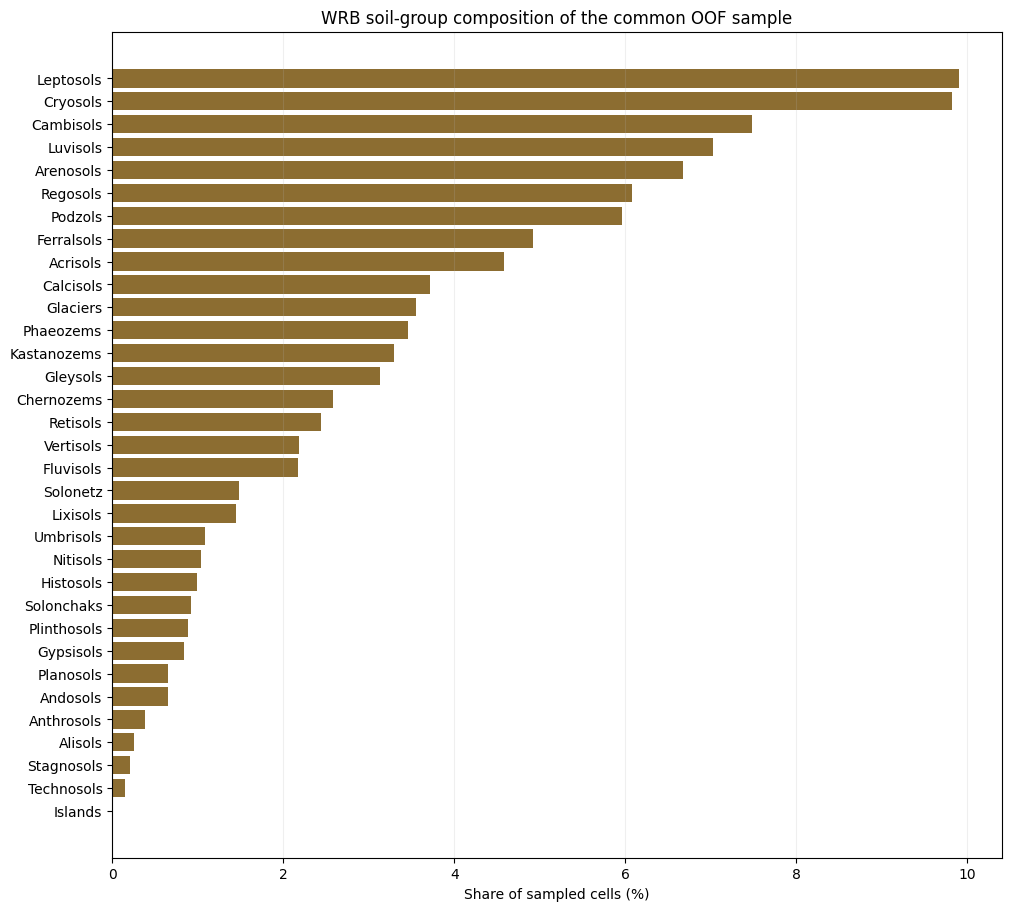

In [5]:
SOIL_LABELS = {
    1: "Acrisols", 2: "Alisols", 3: "Andosols", 4: "Arenosols",
    5: "Anthrosols", 6: "Chernozems", 7: "Calcisols", 8: "Cambisols",
    9: "Cryosols", 10: "Fluvisols", 11: "Ferralsols", 12: "Glaciers",
    13: "Gleysols", 14: "Gypsisols", 15: "Histosols", 16: "Islands",
    17: "Kastanozems", 18: "Leptosols", 19: "Luvisols", 20: "Lixisols",
    21: "Nitisols", 22: "Phaeozems", 23: "Planosols", 24: "Plinthosols",
    25: "Podzols", 26: "Regosols", 27: "Retisols", 28: "Solonchaks",
    29: "Solonetz", 30: "Stagnosols", 31: "Technosols", 32: "Umbrisols",
    33: "Vertisols", 34: "Open Water",
}

soil_codes = sample["soil_group_class"].astype(int)
soil_distribution = (
    soil_codes.value_counts()
    .sort_index()
    .rename_axis("soil_group_class")
    .reset_index(name="n")
)
soil_distribution["soil_group"] = soil_distribution["soil_group_class"].map(SOIL_LABELS)
soil_distribution["share_percent"] = 100 * soil_distribution["n"] / soil_distribution["n"].sum()
display(soil_distribution[["soil_group_class", "soil_group", "n", "share_percent"]].round(3))

technosol_n = int((soil_codes == 31).sum())
print("Technosol sample rows:", f"{technosol_n:,}")
print("Permanent-wetland sample rows:", int((sample["exclusion_class"].astype(int) == 5).sum()))

plot_frame = soil_distribution.sort_values("share_percent")
fig, ax = plt.subplots(figsize=(10, 9), constrained_layout=True)
ax.barh(
    plot_frame["soil_group"],
    plot_frame["share_percent"],
    color="#8C6D31",
)
ax.set_title("WRB soil-group composition of the common OOF sample")
ax.set_xlabel("Share of sampled cells (%)")
ax.grid(axis="x", alpha=0.2)
plt.show()


## 6. 二段階LightGBM・評価・SHAP共通関数


In [6]:
def adjust_probability_prior_shift(
    probability,
    sample_prior,
    population_prior,
    eps=1e-6,
):
    probability = np.clip(np.asarray(probability, dtype=float), eps, 1 - eps)
    sample_prior = float(np.clip(sample_prior, eps, 1 - eps))
    population_prior = float(np.clip(population_prior, eps, 1 - eps))
    odds = probability / (1.0 - probability)
    odds *= (
        (population_prior / (1.0 - population_prior))
        / (sample_prior / (1.0 - sample_prior))
    )
    return odds / (1.0 + odds)


def regression_metrics(y_true, y_pred, weights=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    if weights is None:
        weights = np.ones(len(y_true), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)[valid]

    residual = y_true - y_pred
    observed_mean = np.average(y_true, weights=weights)
    ss_res = np.sum(weights * residual ** 2)
    ss_tot = np.sum(weights * (y_true - observed_mean) ** 2)

    return {
        "n": int(len(y_true)),
        "observed_mean": float(observed_mean),
        "predicted_mean": float(np.average(y_pred, weights=weights)),
        "r2": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
        "rmse": float(np.sqrt(np.average(residual ** 2, weights=weights))),
        "mae": float(np.average(np.abs(residual), weights=weights)),
        "bias_observed_minus_predicted": float(np.average(residual, weights=weights)),
    }


def categorical_features_for(features):
    return [
        feature
        for feature in CATEGORICAL_CANDIDATES
        if feature in features
    ]


def fit_models(train_df, features, fold_number):
    categorical_features = categorical_features_for(features)

    classifier = LGBMClassifier(
        objective="binary",
        n_estimators=450,
        learning_rate=0.035,
        num_leaves=31,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=N_JOBS,
        verbose=-1,
    )
    classifier.fit(
        train_df[features],
        train_df["presence"],
        categorical_feature=categorical_features,
    )

    positive_train = train_df[train_df["presence"].eq(1)]
    regressor = LGBMRegressor(
        objective="regression",
        n_estimators=550,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=60,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=N_JOBS,
        verbose=-1,
    )
    regressor.fit(
        positive_train[features],
        positive_train["cropland_fraction"],
        categorical_feature=categorical_features,
    )
    return classifier, regressor


def extract_tree_shap(explainer, values):
    shap_values = explainer.shap_values(values)
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, -1]
    if shap_values.ndim != 2:
        raise ValueError(f"Unexpected SHAP shape: {shap_values.shape}")
    return shap_values


def select_local_positions(n_rows, max_rows, seed):
    if n_rows <= max_rows:
        return np.arange(n_rows, dtype=int)
    local_rng = np.random.default_rng(seed)
    return np.sort(
        local_rng.choice(n_rows, max_rows, replace=False)
    )


def add_shap_summaries(
    output_rows,
    model_name,
    stage,
    fold_number,
    features,
    shap_values,
    weights,
):
    weights = np.asarray(weights, dtype=float)
    valid_weight = np.isfinite(weights) & (weights > 0)
    if not valid_weight.any():
        weights = np.ones(len(shap_values), dtype=float)
        valid_weight = np.ones(len(shap_values), dtype=bool)

    shap_values = shap_values[valid_weight]
    weights = weights[valid_weight]
    for feature_index, feature in enumerate(features):
        values = shap_values[:, feature_index]
        output_rows.append({
            "model": model_name,
            "stage": stage,
            "fold": fold_number,
            "feature": feature,
            "sum_weight": float(weights.sum()),
            "sum_abs_shap_weighted": float(np.sum(weights * np.abs(values))),
            "sum_signed_shap_weighted": float(np.sum(weights * values)),
            "n": int(len(values)),
        })


## 7. 2モデルの5-fold Spatial OOFとOOF SHAP

2モデル×5fold×二段階を学習する。soilありモデルだけ、各テストfoldから最大1万セルを抽出してOOF SHAPを同時に計算する。


In [7]:
import shap

SOIL_MODEL_NAME = "soil_group_wetland_excluded"
observed = sample["cropland_fraction"].to_numpy(dtype=float)

prediction_by_model = {}
fold_rows = []
shap_rows = []
soil_local_rows = []

for model_number, (model_name, features) in enumerate(MODEL_FEATURES.items(), start=1):
    print("=" * 80)
    print(
        f"MODEL {model_number}/{len(MODEL_FEATURES)}: "
        f"{model_name} ({len(features)} features)"
    )
    print("=" * 80)

    expected_oof = np.full(len(sample), np.nan, dtype=np.float32)

    for fold_number, (train_idx, test_idx) in enumerate(splits, start=1):
        print(f"  fold {fold_number}/{N_SPLITS}")
        train_df = sample.iloc[train_idx]
        test_df = sample.iloc[test_idx]

        classifier, regressor = fit_models(
            train_df,
            features,
            fold_number,
        )

        raw_probability = classifier.predict_proba(test_df[features])[:, 1]
        calibrated_probability = adjust_probability_prior_shift(
            raw_probability,
            float(train_df["presence"].mean()),
            target_prior,
        )
        conditional_fraction = np.clip(
            regressor.predict(test_df[features]),
            0.0,
            1.0,
        )
        expected_fraction = calibrated_probability * conditional_fraction
        expected_oof[test_idx] = expected_fraction.astype(np.float32)

        y_test_presence = test_df["presence"].to_numpy(dtype=np.uint8)
        y_test_fraction = test_df["cropland_fraction"].to_numpy(dtype=float)
        positive_test = y_test_presence == 1

        combined = regression_metrics(y_test_fraction, expected_fraction)
        conditional = regression_metrics(
            y_test_fraction[positive_test],
            conditional_fraction[positive_test],
        )
        fold_rows.append({
            "model": model_name,
            "fold": fold_number,
            "n_features": len(features),
            "combined_r2": combined["r2"],
            "combined_rmse": combined["rmse"],
            "combined_mae": combined["mae"],
            "conditional_r2": conditional["r2"],
            "conditional_rmse": conditional["rmse"],
            "presence_auc": float(
                roc_auc_score(y_test_presence, raw_probability)
            ),
            "presence_average_precision": float(
                average_precision_score(y_test_presence, raw_probability)
            ),
        })

        if model_name == SOIL_MODEL_NAME:
            # Stage 1: presence classifier
            selected_presence = select_local_positions(
                len(test_df),
                SHAP_MAX_ROWS_PER_FOLD,
                RANDOM_SEED + 1000 + fold_number,
            )
            presence_frame = test_df.iloc[selected_presence]
            presence_global_idx = test_idx[selected_presence]
            presence_values = extract_tree_shap(
                shap.TreeExplainer(classifier),
                presence_frame[features],
            )
            presence_weights = (
                area_weight[presence_global_idx]
                if area_weight is not None
                else np.ones(len(presence_frame), dtype=float)
            )
            add_shap_summaries(
                shap_rows,
                model_name,
                "presence_classifier",
                fold_number,
                features,
                presence_values,
                presence_weights,
            )

            soil_feature_index = features.index("soil_group_class")
            soil_local_rows.append(pd.DataFrame({
                "stage": "presence_classifier",
                "fold": fold_number,
                "soil_group_class": presence_frame["soil_group_class"].astype(int).to_numpy(),
                "soil_group_shap": presence_values[:, soil_feature_index],
                "weight": presence_weights,
            }))

            # Stage 2: conditional fraction regressor, positive test cells only
            positive_local = np.flatnonzero(positive_test)
            selected_positive_position = select_local_positions(
                len(positive_local),
                SHAP_MAX_ROWS_PER_FOLD,
                RANDOM_SEED + 2000 + fold_number,
            )
            selected_positive = positive_local[selected_positive_position]
            fraction_frame = test_df.iloc[selected_positive]
            fraction_global_idx = test_idx[selected_positive]
            fraction_values = extract_tree_shap(
                shap.TreeExplainer(regressor),
                fraction_frame[features],
            )
            fraction_weights = (
                area_weight[fraction_global_idx]
                if area_weight is not None
                else np.ones(len(fraction_frame), dtype=float)
            )
            add_shap_summaries(
                shap_rows,
                model_name,
                "conditional_fraction_regressor",
                fold_number,
                features,
                fraction_values,
                fraction_weights,
            )
            soil_local_rows.append(pd.DataFrame({
                "stage": "conditional_fraction_regressor",
                "fold": fold_number,
                "soil_group_class": fraction_frame["soil_group_class"].astype(int).to_numpy(),
                "soil_group_shap": fraction_values[:, soil_feature_index],
                "weight": fraction_weights,
            }))

        del classifier, regressor
        del raw_probability, calibrated_probability
        del conditional_fraction, expected_fraction
        gc.collect()

    if not np.isfinite(expected_oof).all():
        raise RuntimeError(f"OOF prediction is incomplete: {model_name}")
    prediction_by_model[model_name] = expected_oof

fold_metrics = pd.DataFrame(fold_rows)

global_rows = []
weight_specs = {"unweighted_sample": None}
if area_weight is not None:
    weight_specs["area_weighted_reweighted"] = area_weight

for model_name, prediction in prediction_by_model.items():
    for weighting, weights in weight_specs.items():
        global_rows.append({
            "model": model_name,
            "weighting": weighting,
            "n_features": len(MODEL_FEATURES[model_name]),
            **regression_metrics(observed, prediction, weights=weights),
        })

global_metrics = pd.DataFrame(global_rows)
shap_fold_summary = pd.DataFrame(shap_rows)
soil_local_shap = pd.concat(soil_local_rows, ignore_index=True)

prediction_table = sample[
    [
        "row", "col", "lat", "lon", "spatial_block",
        "presence", "cropland_fraction", "exclusion_class",
        "soil_group_class",
    ]
].copy()
for model_name, prediction in prediction_by_model.items():
    prediction_table[f"pred_{model_name}"] = prediction

fold_metrics.to_csv(
    OUTPUT_DIR / "soil_comparison_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
global_metrics.to_csv(
    OUTPUT_DIR / "soil_comparison_global_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
prediction_table.to_csv(
    OUTPUT_DIR / "soil_comparison_oof_predictions.csv.gz",
    index=False,
    compression="gzip",
)
shap_fold_summary.to_csv(
    OUTPUT_DIR / "soil_model_oof_shap_fold_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
soil_local_shap.to_csv(
    OUTPUT_DIR / "soil_group_oof_local_shap.csv.gz",
    index=False,
    compression="gzip",
)
print("OOF and SHAP completed.")


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MODEL 1/2: no_soil_wetland_excluded (14 features)
  fold 1/5
  fold 2/5
  fold 3/5
  fold 4/5
  fold 5/5
MODEL 2/2: soil_group_wetland_excluded (15 features)
  fold 1/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


  fold 2/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


...

  fold 4/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


  fold 5/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


OOF and SHAP completed.


## 8. OOF精度：soilなし vs soilあり


,model,weighting,n_features,n,observed_mean,predicted_mean,r2,rmse,mae,bias_observed_minus_predicted
3,soil_group_wetland_excluded,area_weighted_reweighted,15,240000,0.116793,0.111519,0.609591,0.131135,0.071251,0.005274
1,no_soil_wetland_excluded,area_weighted_reweighted,14,240000,0.116793,0.111563,0.577795,0.136370,0.075086,0.005230
2,soil_group_wetland_excluded,unweighted_sample,15,240000,0.140323,0.127384,0.622410,0.136851,0.076815,0.012939
0,no_soil_wetland_excluded,unweighted_sample,14,240000,0.140323,0.126064,0.586757,0.143166,0.081517,0.014259


,weighting,delta_r2_soil_minus_no_soil,delta_rmse_soil_minus_no_soil,delta_mae_soil_minus_no_soil
0,unweighted_sample,0.035653,-0.006315,-0.004701
1,area_weighted_reweighted,0.031795,-0.005235,-0.003835


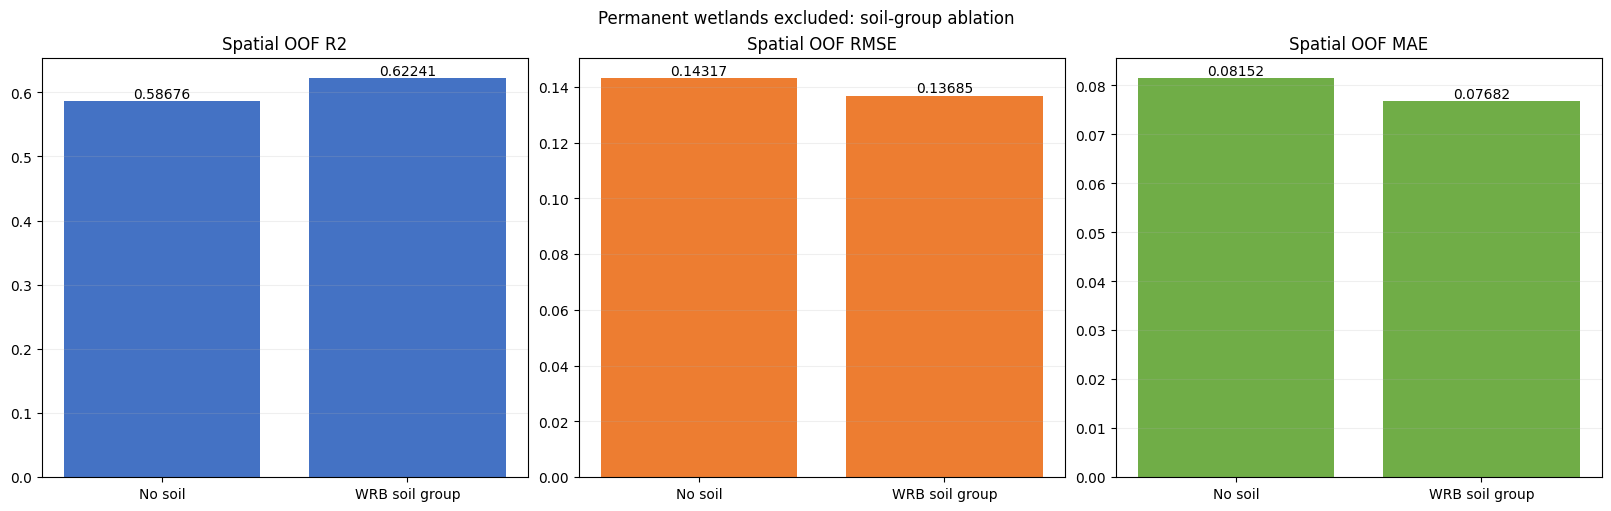

In [8]:
display(
    global_metrics.sort_values(["weighting", "r2"], ascending=[True, False])
    .round(6)
)

baseline_name = "no_soil_wetland_excluded"
soil_name = "soil_group_wetland_excluded"

comparison_rows = []
for weighting in global_metrics["weighting"].unique():
    sub = global_metrics[global_metrics["weighting"].eq(weighting)].set_index("model")
    baseline = sub.loc[baseline_name]
    soil_result = sub.loc[soil_name]
    comparison_rows.append({
        "weighting": weighting,
        "delta_r2_soil_minus_no_soil": soil_result["r2"] - baseline["r2"],
        "delta_rmse_soil_minus_no_soil": soil_result["rmse"] - baseline["rmse"],
        "delta_mae_soil_minus_no_soil": soil_result["mae"] - baseline["mae"],
    })

soil_delta = pd.DataFrame(comparison_rows)
display(soil_delta.round(6))
soil_delta.to_csv(
    OUTPUT_DIR / "soil_model_metric_deltas.csv",
    index=False,
    encoding="utf-8-sig",
)

unweighted = (
    global_metrics[global_metrics["weighting"].eq("unweighted_sample")]
    .set_index("model")
    .loc[[baseline_name, soil_name]]
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
for ax, metric, color in zip(
    axes,
    ["r2", "rmse", "mae"],
    ["#4472C4", "#ED7D31", "#70AD47"],
):
    ax.bar(
        ["No soil", "WRB soil group"],
        unweighted[metric],
        color=color,
    )
    ax.set_title(f"Spatial OOF {metric.upper()}")
    ax.grid(axis="y", alpha=0.2)
    for x, value in enumerate(unweighted[metric]):
        ax.text(x, value, f"{value:.5f}", ha="center", va="bottom")

fig.suptitle("Permanent wetlands excluded: soil-group ablation")
plt.show()


## 9. 残差Moran's Iと空間分布


,model,morans_i,expected_i,n,k
1,soil_group_wetland_excluded,0.465731,-0.00002,50000,8
0,no_soil_wetland_excluded,0.505620,-0.00002,50000,8


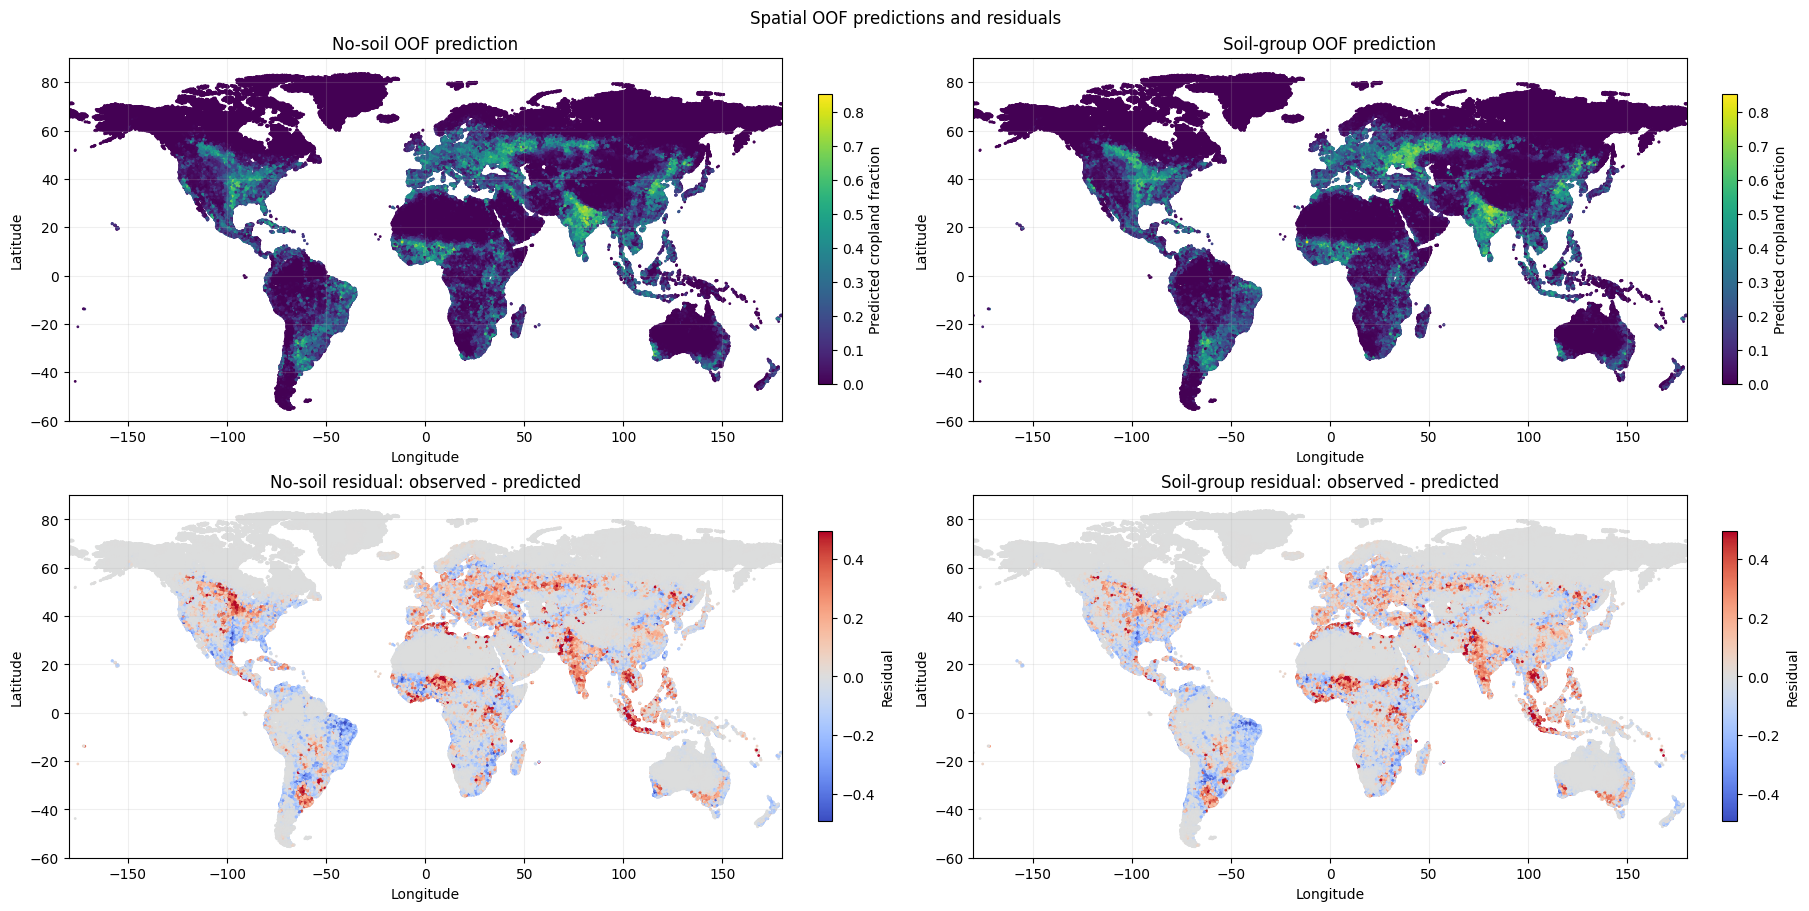

In [9]:
def morans_i_knn(
    frame,
    residual,
    k=MORAN_K,
    max_n=MORAN_MAX_N,
    seed=RANDOM_SEED + 7000,
):
    residual = np.asarray(residual, dtype=float)
    coords = frame[["lat", "lon"]].to_numpy(dtype=float)
    valid = np.isfinite(residual) & np.isfinite(coords).all(axis=1)
    valid_idx = np.flatnonzero(valid)

    if len(valid_idx) > max_n:
        local_rng = np.random.default_rng(seed)
        valid_idx = np.sort(
            local_rng.choice(valid_idx, max_n, replace=False)
        )

    selected_residual = residual[valid_idx]
    selected_coords = np.radians(coords[valid_idx])
    centered = selected_residual - selected_residual.mean()

    tree = BallTree(selected_coords, metric="haversine")
    _, neighbor_idx = tree.query(
        selected_coords,
        k=min(k + 1, len(selected_coords)),
    )
    neighbor_idx = neighbor_idx[:, 1:]

    denominator = np.sum(centered ** 2)
    numerator = np.sum(centered[:, None] * centered[neighbor_idx])
    actual_k = neighbor_idx.shape[1]
    morans_i = numerator / (actual_k * denominator)

    return {
        "morans_i": float(morans_i),
        "expected_i": float(-1.0 / (len(selected_residual) - 1)),
        "n": int(len(selected_residual)),
        "k": int(actual_k),
    }


moran_rows = []
for model_name, prediction in prediction_by_model.items():
    residual = observed - np.asarray(prediction, dtype=float)
    moran_rows.append({
        "model": model_name,
        **morans_i_knn(sample, residual),
    })

moran_results = pd.DataFrame(moran_rows).sort_values("morans_i")
display(moran_results.round(6))
moran_results.to_csv(
    OUTPUT_DIR / "soil_comparison_residual_morans_i.csv",
    index=False,
    encoding="utf-8-sig",
)

baseline_prediction = prediction_by_model[baseline_name]
soil_prediction = prediction_by_model[soil_name]
baseline_residual = observed - baseline_prediction
soil_residual = observed - soil_prediction

prediction_vmax = float(np.quantile(observed, 0.995))
residual_limit = float(
    np.quantile(
        np.abs(np.concatenate([baseline_residual, soil_residual])),
        0.99,
    )
)

fig, axes = plt.subplots(2, 2, figsize=(18, 9), constrained_layout=True)

top_specs = [
    (baseline_prediction, "No-soil OOF prediction"),
    (soil_prediction, "Soil-group OOF prediction"),
]
for ax, (values, title) in zip(axes[0], top_specs):
    scatter = ax.scatter(
        sample["lon"], sample["lat"],
        c=values, s=1.0, cmap="viridis",
        vmin=0, vmax=prediction_vmax, rasterized=True,
    )
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax, shrink=0.8, label="Predicted cropland fraction")

bottom_specs = [
    (baseline_residual, "No-soil residual: observed - predicted"),
    (soil_residual, "Soil-group residual: observed - predicted"),
]
for ax, (values, title) in zip(axes[1], bottom_specs):
    scatter = ax.scatter(
        sample["lon"], sample["lat"],
        c=values, s=1.0, cmap="coolwarm",
        vmin=-residual_limit, vmax=residual_limit, rasterized=True,
    )
    ax.set_title(title)
    fig.colorbar(scatter, ax=ax, shrink=0.8, label="Residual")

for ax in axes.flat:
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 90)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.2)

fig.suptitle("Spatial OOF predictions and residuals")
plt.show()


## 10. OOF SHAP：個別変数重要度と土壌クラス別寄与


,stage,feature,mean_abs_shap,mean_signed_shap,relative_importance_share
4,conditional_fraction_regressor,log_city_time_20k_min,0.059947,0.001657,0.207127
11,conditional_fraction_regressor,soil_group_class,0.042315,-0.008064,0.146203
10,conditional_fraction_regressor,slope,0.040979,-0.000225,0.141590
1,conditional_fraction_regressor,exclusion_class,0.027043,0.000821,0.093438
0,conditional_fraction_regressor,elevation_m,0.018979,-0.003534,0.065575
7,conditional_fraction_regressor,log_port_time_any_min,0.012803,-0.001154,0.044236
2,conditional_fraction_regressor,irrigation_calorie_gain_top5_raw,0.012772,0.000687,0.044128
9,conditional_fraction_regressor,rainfed_value_top5_raw,0.012014,-0.002186,0.041509
8,conditional_fraction_regressor,rainfed_calorie_top5_raw,0.011643,0.000589,0.040228
3,conditional_fraction_regressor,irrigation_value_gain_top5_raw,0.011375,-0.000660,0.039302


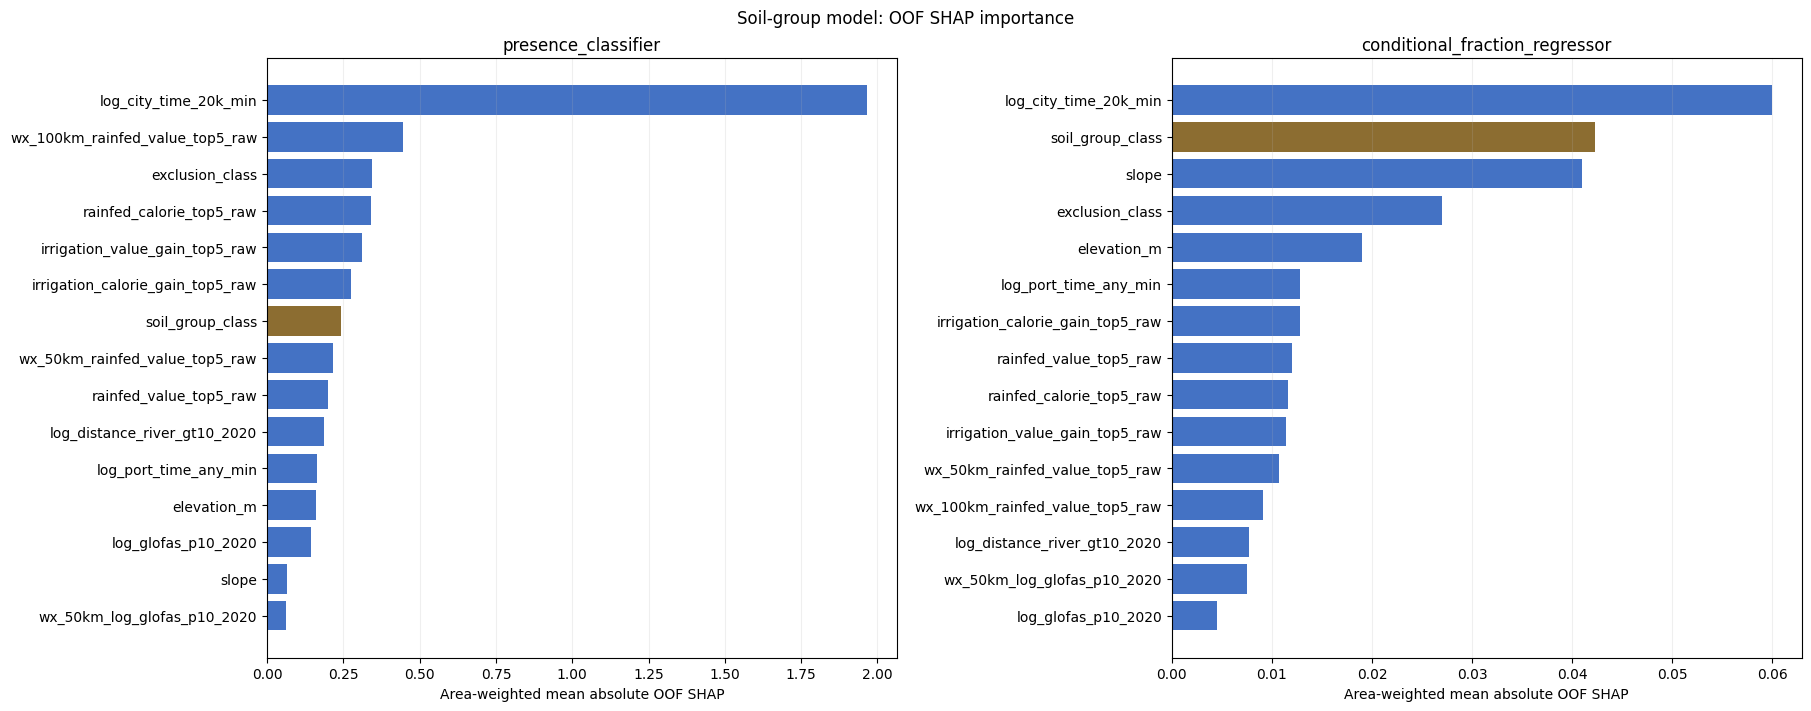

,stage,soil_group_class,soil_group,n,mean_signed_shap,mean_abs_shap
5,conditional_fraction_regressor,6,Chernozems,2487,0.186346,0.186346
29,conditional_fraction_regressor,31,Technosols,108,-0.092719,0.092719
20,conditional_fraction_regressor,22,Phaeozems,3135,0.081739,0.081778
23,conditional_fraction_regressor,25,Podzols,1480,-0.078577,0.078577
13,conditional_fraction_regressor,14,Gypsisols,209,-0.076283,0.076319
...,...,...,...,...,...,...
49,presence_classifier,18,Leptosols,4979,-0.054366,0.095381
50,presence_classifier,19,Luvisols,3504,0.036827,0.092283
61,presence_classifier,30,Stagnosols,98,0.036873,0.089562
39,presence_classifier,8,Cambisols,3757,0.011114,0.081804


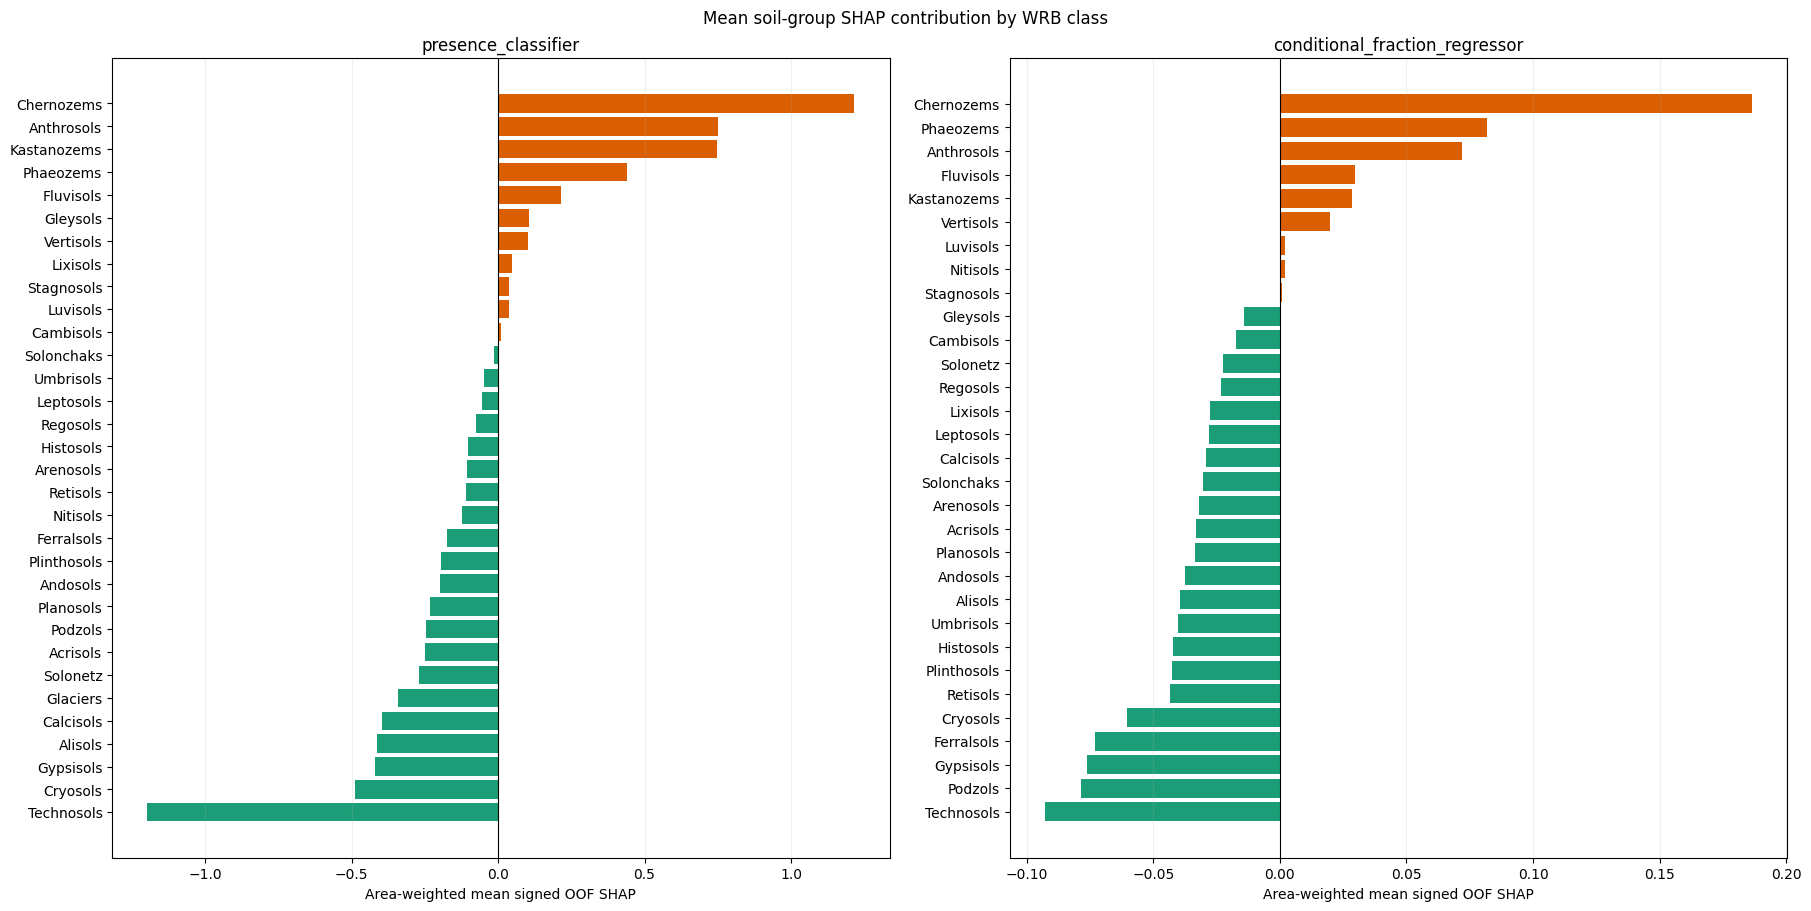

In [11]:
shap_summary = (
    shap_fold_summary.groupby(["model", "stage", "feature"], as_index=False)
    [["sum_weight", "sum_abs_shap_weighted", "sum_signed_shap_weighted", "n"]]
    .sum()
)
shap_summary["mean_abs_shap"] = (
    shap_summary["sum_abs_shap_weighted"] / shap_summary["sum_weight"]
)
shap_summary["mean_signed_shap"] = (
    shap_summary["sum_signed_shap_weighted"] / shap_summary["sum_weight"]
)
shap_summary["relative_importance_share"] = (
    shap_summary["mean_abs_shap"]
    / shap_summary.groupby("stage")["mean_abs_shap"].transform("sum")
)
shap_summary.to_csv(
    OUTPUT_DIR / "soil_model_oof_shap_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

display(
    shap_summary.sort_values(["stage", "mean_abs_shap"], ascending=[True, False])
    [[
        "stage", "feature", "mean_abs_shap",
        "mean_signed_shap", "relative_importance_share",
    ]]
    .round(6)
)

stages = ["presence_classifier", "conditional_fraction_regressor"]
fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
for ax, stage in zip(axes, stages):
    plot_frame = (
        shap_summary[shap_summary["stage"].eq(stage)]
        .sort_values("mean_abs_shap", ascending=True)
    )
    colors = np.where(
        plot_frame["feature"].eq("soil_group_class"),
        "#8C6D31",
        "#4472C4",
    )
    ax.barh(plot_frame["feature"], plot_frame["mean_abs_shap"], color=colors)
    ax.set_title(stage)
    ax.set_xlabel("Area-weighted mean absolute OOF SHAP")
    ax.grid(axis="x", alpha=0.2)

fig.suptitle("Soil-group model: OOF SHAP importance")
plt.show()

soil_local_shap["soil_group"] = (
    soil_local_shap["soil_group_class"].map(SOIL_LABELS)
)

soil_group_rows = []
for (stage, code_value, label), group in soil_local_shap.groupby(
    ["stage", "soil_group_class", "soil_group"],
    dropna=False,
):
    weights = group["weight"].to_numpy(dtype=float)
    values = group["soil_group_shap"].to_numpy(dtype=float)
    soil_group_rows.append({
        "stage": stage,
        "soil_group_class": int(code_value),
        "soil_group": label,
        "n": len(group),
        "mean_signed_shap": float(np.average(values, weights=weights)),
        "mean_abs_shap": float(np.average(np.abs(values), weights=weights)),
    })

soil_group_shap_summary = pd.DataFrame(soil_group_rows)
soil_group_shap_summary.to_csv(
    OUTPUT_DIR / "soil_group_class_oof_shap_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
display(
    soil_group_shap_summary.sort_values(
        ["stage", "mean_abs_shap"],
        ascending=[True, False],
    ).round(6)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)
for ax, stage in zip(axes, stages):
    plot_frame = (
        soil_group_shap_summary[
            soil_group_shap_summary["stage"].eq(stage)
            & soil_group_shap_summary["n"].ge(30)
        ]
        .sort_values("mean_signed_shap")
    )
    colors = np.where(
        plot_frame["mean_signed_shap"] >= 0,
        "#D95F02",
        "#1B9E77",
    )
    ax.barh(
        plot_frame["soil_group"],
        plot_frame["mean_signed_shap"],
        color=colors,
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(stage)
    ax.set_xlabel("Area-weighted mean signed OOF SHAP")
    ax.grid(axis="x", alpha=0.2)

fig.suptitle("Mean soil-group SHAP contribution by WRB class")
plt.show()


## 11. 判断基準

### 土壌分類を残す根拠

- soilありモデルのSpatial OOF R²が改善する。
- RMSE・MAEも悪化しない。
- 残差Moran's Iが少なくとも大きく悪化しない。
- `soil_group_class`のSHAPがTechnosolsだけではなく複数の自然土壌クラスで変化する。

### 注意

- Stage 1のSHAPは分類器のraw score（log-odds）への寄与、Stage 2は耕作地割合への寄与であり、両者の数値を直接比較・加算しない。
- WRB土壌グループは土壌資本の粗いカテゴリ代理変数である。効果が確認できた場合、次にpH、土壌有機炭素、根域深度、保水力、排水・酸素条件などの連続的土壌特性へ進む。
- 今回は恒久湿地をmodeで代表される5分格子単位で除外している。湿地面積割合による分母調整は別の感度分析である。


## 12 まとめると

All model features are assigned to exactly one factor group.


,stage,factor_group,n_features,group_mean_abs_shap,mean_abs_shap_per_feature,group_mean_signed_shap,importance_share_percent
0,conditional_fraction_regressor,Climate and water capital,9,0.087356,0.009706,-0.004682,30.182946
1,conditional_fraction_regressor,Land and soil capital,4,0.129316,0.032329,-0.011002,44.680713
2,conditional_fraction_regressor,Market access and infrastructure,2,0.072750,0.036375,0.000503,25.136342
3,presence_classifier,Climate and water capital,9,2.181561,0.242396,-0.102393,42.620100
4,presence_classifier,Land and soil capital,4,0.808606,0.202152,-0.114698,15.797349
5,presence_classifier,Market access and infrastructure,2,2.128453,1.064227,0.179924,41.582551


saved: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_wetland_excluded\soil_model_oof_shap_factor_groups.csv


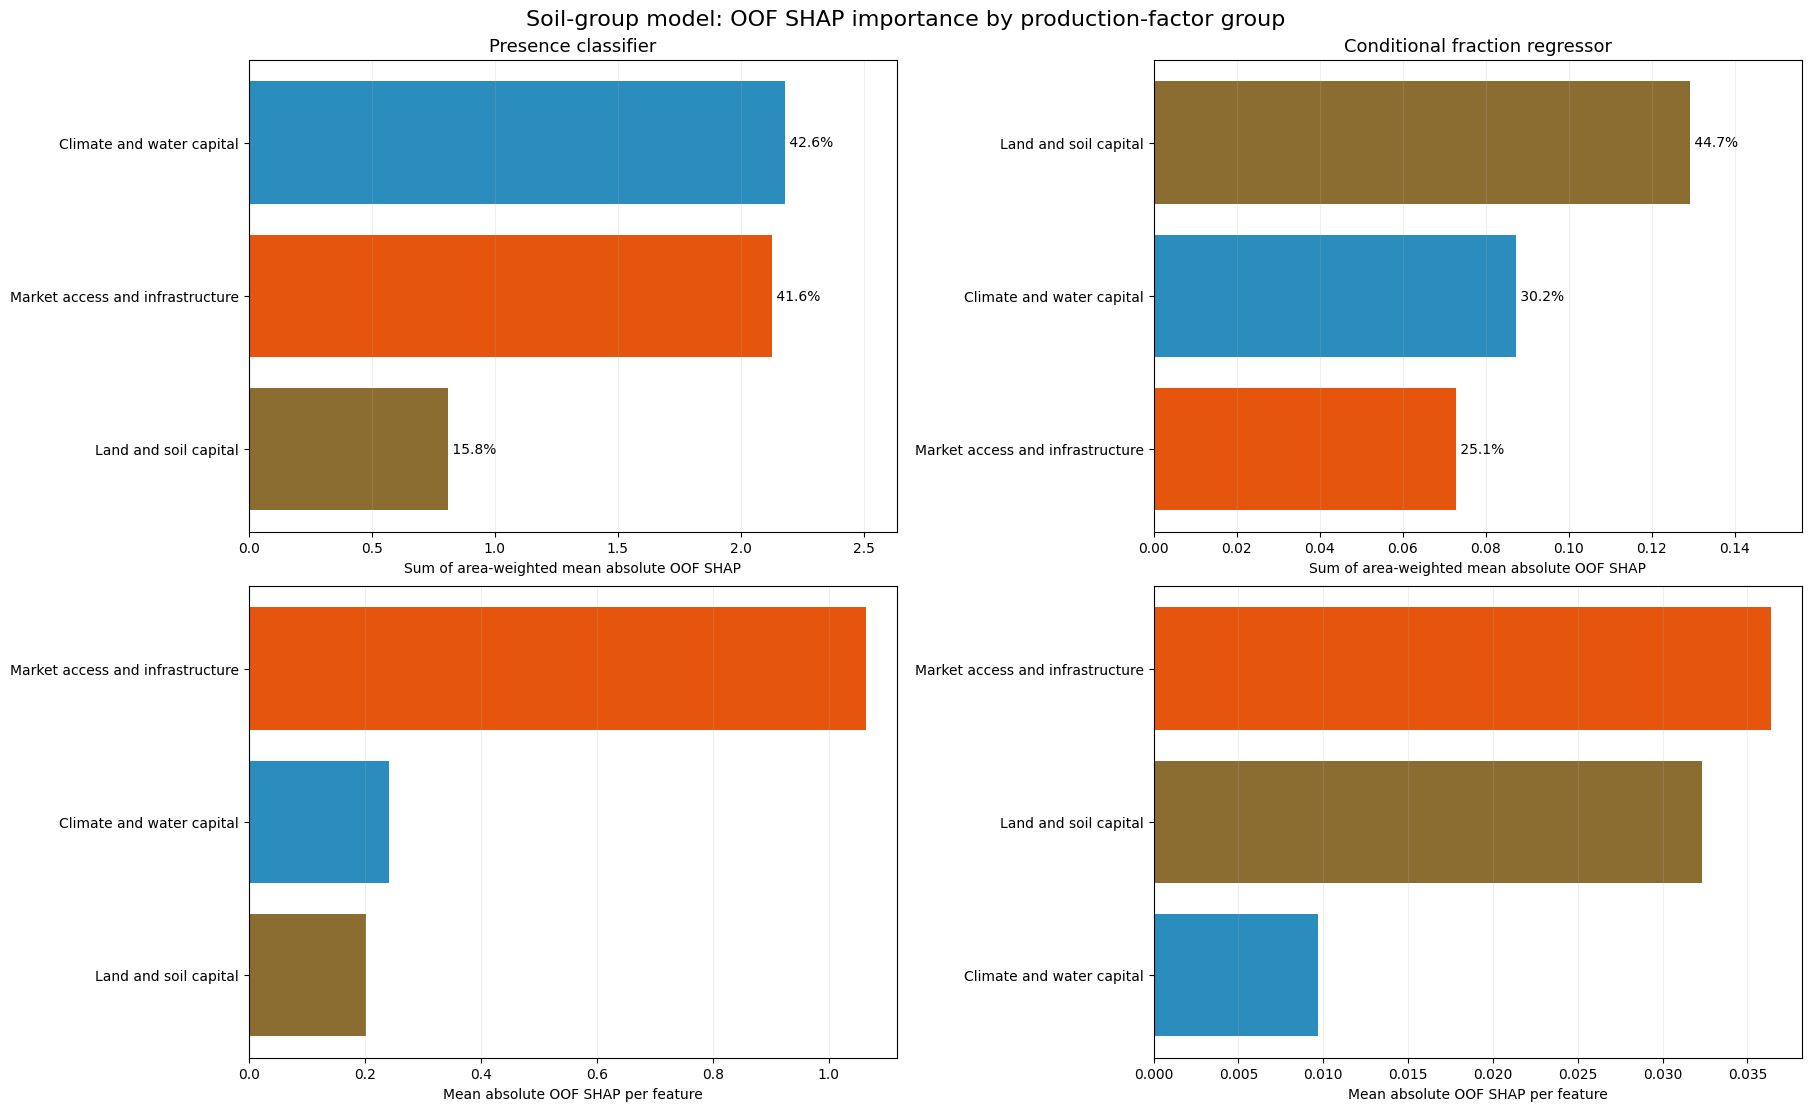

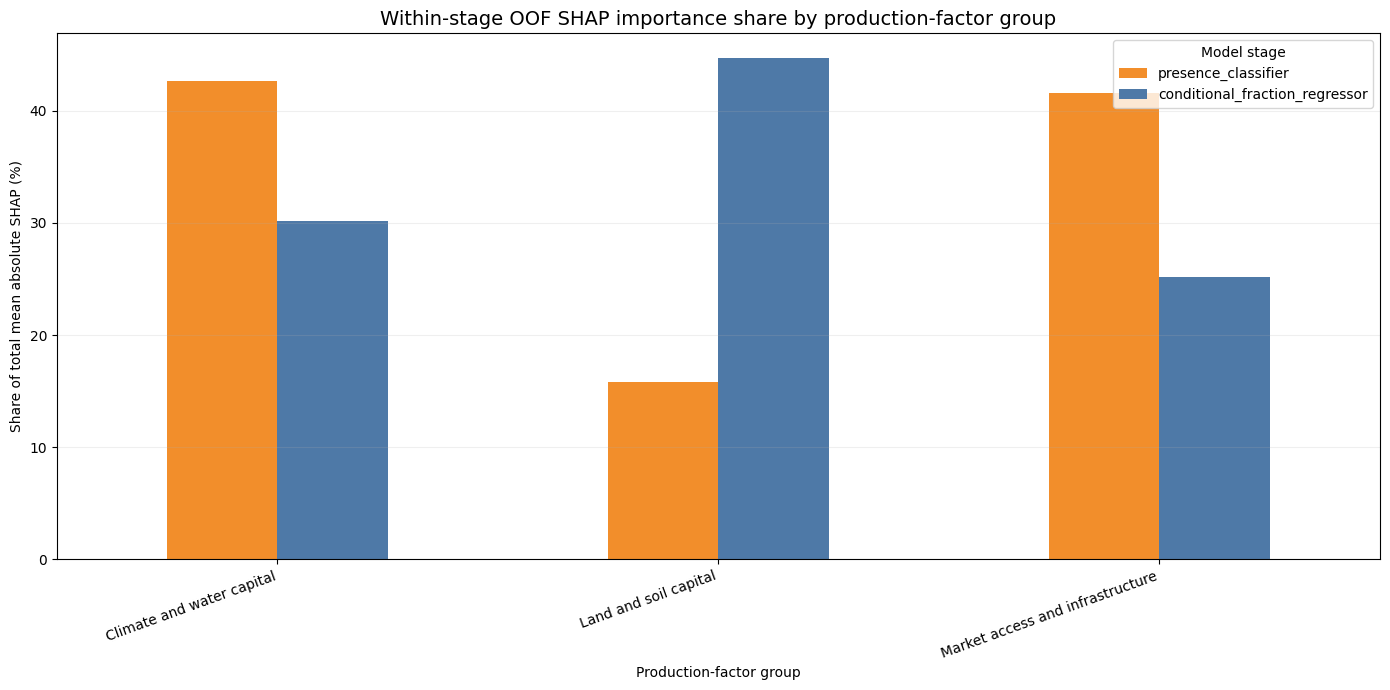

,final_factor,included_in_current_cropland_model,note
0,Climate and water capital,True,"Climate potential, water resources and irrigat..."
1,Land and soil capital,True,"Elevation, slope, exclusion class and soil group"
2,Labor input,False,No labor variable in the current model
3,Human capital,False,"No education, skill or health variable"
4,Physical and technological capital,False,"No actual irrigation, machinery or fertilizer ..."
5,Market access and infrastructure,True,Travel time to cities and ports
6,Institutions and policy,False,No institutional or policy variable


In [13]:
# ============================================================
# 生産要素グループ別 OOF SHAP
# ============================================================

# 現在の耕作地モデルに実際に含まれている生産要素：
#
# 1. Climate and water capital
# 2. Land and soil capital
# 3. Market access and infrastructure
#
# 労働投入、人的資本、物的・技術資本、制度・政策は、
# 現在の耕作地モデルには対応する説明変数が入っていないため、
# この段階のSHAPグラフには表示しない。


# ------------------------------------------------------------
# 0. 必要なSHAP集計表を確認
# ------------------------------------------------------------

if "shap_summary" not in globals():
    shap_summary_path = (
        OUTPUT_DIR
        / "soil_model_oof_shap_summary.csv"
    )

    if not shap_summary_path.exists():
        raise FileNotFoundError(
            "shap_summaryがありません。先に個別変数の"
            "OOF SHAP計算セルを実行してください。"
        )

    shap_summary = pd.read_csv(
        shap_summary_path
    )


required_objects = [
    "MODEL_FEATURES",
    "SOIL_MODEL_NAME",
    "OUTPUT_DIR",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "必要な変数がありません。"
        f"不足: {missing_objects}"
    )


# ------------------------------------------------------------
# 1. 最終的な生産要素分類
# ------------------------------------------------------------

FACTOR_GROUPS = {
    "Climate and water capital": [
        # 現地の水資源条件
        "log_glofas_p10_2020",
        "log_distance_river_gt10_2020",

        # 周辺50 kmの水資源条件
        "wx_50km_log_glofas_p10_2020",

        # 天水条件での農業ポテンシャル
        "rainfed_value_top5_raw",
        "rainfed_calorie_top5_raw",

        # 周辺の天水農業ポテンシャル
        "wx_50km_rainfed_value_top5_raw",
        "wx_100km_rainfed_value_top5_raw",

        # 灌漑した場合の潜在的改善幅
        #
        # これは「実際に灌漑しているか」ではないため、
        # 物的・技術資本ではなく、
        # 灌漑に対する自然地理的ポテンシャルとして扱う。
        "irrigation_value_gain_top5_raw",
        "irrigation_calorie_gain_top5_raw",
    ],

    "Land and soil capital": [
        "elevation_m",
        "slope",
        "exclusion_class",
        "soil_group_class",
    ],

    "Market access and infrastructure": [
        "log_city_time_20k_min",
        "log_port_time_any_min",
    ],
}


# グラフで使用する順序
FACTOR_ORDER = [
    "Climate and water capital",
    "Land and soil capital",
    "Market access and infrastructure",
]


# 各グループの色
FACTOR_COLORS = {
    "Climate and water capital":
        "#2B8CBE",

    "Land and soil capital":
        "#8C6D31",

    "Market access and infrastructure":
        "#E6550D",
}


# ------------------------------------------------------------
# 2. 変数名から生産要素への対応表を作成
# ------------------------------------------------------------

feature_to_factor = {
    feature: factor
    for factor, features in FACTOR_GROUPS.items()
    for feature in features
}


# 同じ変数が複数のグループに入っていないか確認
all_group_features = [
    feature
    for features in FACTOR_GROUPS.values()
    for feature in features
]

duplicated_features = sorted({
    feature
    for feature in all_group_features
    if all_group_features.count(feature) > 1
})

if duplicated_features:
    raise ValueError(
        "複数の要素グループに重複している変数があります: "
        f"{duplicated_features}"
    )


# ------------------------------------------------------------
# 3. モデル変数とグループ定義が一致するか確認
# ------------------------------------------------------------

soil_model_features = set(
    MODEL_FEATURES[SOIL_MODEL_NAME]
)

grouped_features = set(
    feature_to_factor
)


# モデルにはあるが、グループに割り当てていない変数
missing_from_groups = sorted(
    soil_model_features
    - grouped_features
)


# グループにはあるが、モデルに入っていない変数
unknown_in_groups = sorted(
    grouped_features
    - soil_model_features
)


if missing_from_groups or unknown_in_groups:
    raise ValueError(
        "生産要素グループの定義とモデル変数が一致しません。\n"
        f"グループ分けされていないモデル変数: "
        f"{missing_from_groups}\n"
        f"モデルに存在しないグループ変数: "
        f"{unknown_in_groups}"
    )

print(
    "All model features are assigned "
    "to exactly one factor group."
)


# ------------------------------------------------------------
# 4. 土壌ありモデルの個別変数SHAPを抽出
# ------------------------------------------------------------

factor_source = shap_summary[
    shap_summary["model"].eq(
        SOIL_MODEL_NAME
    )
].copy()


if factor_source.empty:
    raise ValueError(
        f"{SOIL_MODEL_NAME} のSHAP結果がありません。"
    )


factor_source["factor_group"] = (
    factor_source["feature"]
    .map(feature_to_factor)
)


if factor_source["factor_group"].isna().any():
    unmapped = sorted(
        factor_source.loc[
            factor_source["factor_group"].isna(),
            "feature",
        ].unique()
    )

    raise ValueError(
        "グループに割り当てられていない"
        f"SHAP変数があります: {unmapped}"
    )


# ------------------------------------------------------------
# 5. 生産要素グループ単位にSHAPを集計
# ------------------------------------------------------------

factor_shap_summary = (
    factor_source
    .groupby(
        [
            "stage",
            "factor_group",
        ],
        as_index=False,
    )
    .agg(
        # グループ内の個別変数について、
        # area-weighted mean absolute SHAPを合計
        group_mean_abs_shap=(
            "mean_abs_shap",
            "sum",
        ),

        # グループ内の符号付き平均SHAPを合計
        group_mean_signed_shap=(
            "mean_signed_shap",
            "sum",
        ),

        # グループ内の変数数
        n_features=(
            "feature",
            "nunique",
        ),
    )
)


# ------------------------------------------------------------
# 6. 1変数当たり平均と構成比を計算
# ------------------------------------------------------------

# グループに含まれる変数数が多いことで
# SHAP合計が大きくなっていないかを見る参考指標
factor_shap_summary[
    "mean_abs_shap_per_feature"
] = (
    factor_shap_summary[
        "group_mean_abs_shap"
    ]
    / factor_shap_summary[
        "n_features"
    ]
)


# 各段階のSHAP重要度合計に占める割合
factor_shap_summary[
    "importance_share_percent"
] = (
    100.0
    * factor_shap_summary[
        "group_mean_abs_shap"
    ]
    / factor_shap_summary
        .groupby("stage")[
            "group_mean_abs_shap"
        ]
        .transform("sum")
)


# 表示順を固定
factor_shap_summary[
    "factor_group"
] = pd.Categorical(
    factor_shap_summary[
        "factor_group"
    ],
    categories=FACTOR_ORDER,
    ordered=True,
)


factor_shap_summary = (
    factor_shap_summary
    .sort_values(
        [
            "stage",
            "factor_group",
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. 結果表を保存
# ------------------------------------------------------------

factor_output_path = (
    OUTPUT_DIR
    / "soil_model_oof_shap_factor_groups.csv"
)


factor_shap_summary.to_csv(
    factor_output_path,
    index=False,
    encoding="utf-8-sig",
)


display_columns = [
    "stage",
    "factor_group",
    "n_features",
    "group_mean_abs_shap",
    "mean_abs_shap_per_feature",
    "group_mean_signed_shap",
    "importance_share_percent",
]


display(
    factor_shap_summary[
        display_columns
    ].round(6)
)


print(
    "saved:",
    factor_output_path,
)


# ------------------------------------------------------------
# 8. 段階名と表示順
# ------------------------------------------------------------

STAGES = [
    "presence_classifier",
    "conditional_fraction_regressor",
]


STAGE_TITLES = {
    "presence_classifier":
        "Presence classifier",

    "conditional_fraction_regressor":
        "Conditional fraction regressor",
}


# ------------------------------------------------------------
# 9. グループSHAP合計と1変数当たり平均
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(18, 11),
    constrained_layout=True,
)


for column, stage in enumerate(STAGES):

    stage_frame = (
        factor_shap_summary[
            factor_shap_summary[
                "stage"
            ].eq(stage)
        ]
        .copy()
    )


    # グラフ上では値の小さい順に並べる
    total_frame = (
        stage_frame
        .sort_values(
            "group_mean_abs_shap",
            ascending=True,
        )
    )


    # -------------------------
    # 上段：グループSHAP合計
    # -------------------------

    ax = axes[0, column]


    bars = ax.barh(
        total_frame[
            "factor_group"
        ].astype(str),

        total_frame[
            "group_mean_abs_shap"
        ],

        color=[
            FACTOR_COLORS[
                factor
            ]
            for factor
            in total_frame[
                "factor_group"
            ].astype(str)
        ],
    )


    # 棒の右側に段階内構成比を表示
    for bar, share in zip(
        bars,
        total_frame[
            "importance_share_percent"
        ],
    ):
        ax.text(
            bar.get_width(),
            (
                bar.get_y()
                + bar.get_height() / 2
            ),
            f" {share:.1f}%",
            va="center",
            ha="left",
            fontsize=10,
        )


    ax.set_title(
        STAGE_TITLES[stage],
        fontsize=13,
    )

    ax.set_xlabel(
        "Sum of area-weighted "
        "mean absolute OOF SHAP"
    )

    ax.grid(
        axis="x",
        alpha=0.2,
    )


    # 右側のラベルが切れないよう余白を追加
    current_limit = ax.get_xlim()

    ax.set_xlim(
        current_limit[0],
        current_limit[1] * 1.15,
    )


    # -------------------------
    # 下段：1変数当たりSHAP
    # -------------------------

    average_frame = (
        stage_frame
        .sort_values(
            "mean_abs_shap_per_feature",
            ascending=True,
        )
    )


    ax = axes[1, column]


    ax.barh(
        average_frame[
            "factor_group"
        ].astype(str),

        average_frame[
            "mean_abs_shap_per_feature"
        ],

        color=[
            FACTOR_COLORS[
                factor
            ]
            for factor
            in average_frame[
                "factor_group"
            ].astype(str)
        ],
    )


    ax.set_xlabel(
        "Mean absolute OOF SHAP "
        "per feature"
    )

    ax.grid(
        axis="x",
        alpha=0.2,
    )


fig.suptitle(
    "Soil-group model: "
    "OOF SHAP importance "
    "by production-factor group",
    fontsize=16,
)


plt.show()


# ------------------------------------------------------------
# 10. 各段階のSHAP重要度構成比
# ------------------------------------------------------------

share_table = (
    factor_shap_summary
    .pivot(
        index="factor_group",
        columns="stage",
        values="importance_share_percent",
    )
    .reindex(
        FACTOR_ORDER
    )
    .reindex(
        columns=STAGES
    )
)


ax = share_table.plot.bar(
    figsize=(14, 7),

    color={
        "presence_classifier":
            "#F28E2B",

        "conditional_fraction_regressor":
            "#4E79A7",
    },
)


ax.set_title(
    "Within-stage OOF SHAP "
    "importance share "
    "by production-factor group",
    fontsize=14,
)


ax.set_xlabel(
    "Production-factor group"
)


ax.set_ylabel(
    "Share of total "
    "mean absolute SHAP (%)"
)


ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=20,
    ha="right",
)


ax.grid(
    axis="y",
    alpha=0.2,
)


ax.legend(
    title="Model stage"
)


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. 現在モデルに入っていない最終要素を明示
# ------------------------------------------------------------

final_factor_coverage = pd.DataFrame({
    "final_factor": [
        "Climate and water capital",
        "Land and soil capital",
        "Labor input",
        "Human capital",
        "Physical and technological capital",
        "Market access and infrastructure",
        "Institutions and policy",
    ],

    "included_in_current_cropland_model": [
        True,
        True,
        False,
        False,
        False,
        True,
        False,
    ],

    "note": [
        "Climate potential, water resources and irrigation potential",
        "Elevation, slope, exclusion class and soil group",
        "No labor variable in the current model",
        "No education, skill or health variable",
        "No actual irrigation, machinery or fertilizer variable",
        "Travel time to cities and ports",
        "No institutional or policy variable",
    ],
})


display(
    final_factor_coverage
)

## 13　説明変数とshap値の関係を図示

OOF SHAP fold 1/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


OOF SHAP fold 2/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


OOF SHAP fold 3/5


...

OOF SHAP fold 4/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


OOF SHAP fold 5/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


local SHAP rows: 100,000
saved: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_wetland_excluded\soil_model_oof_local_feature_shap.csv.gz


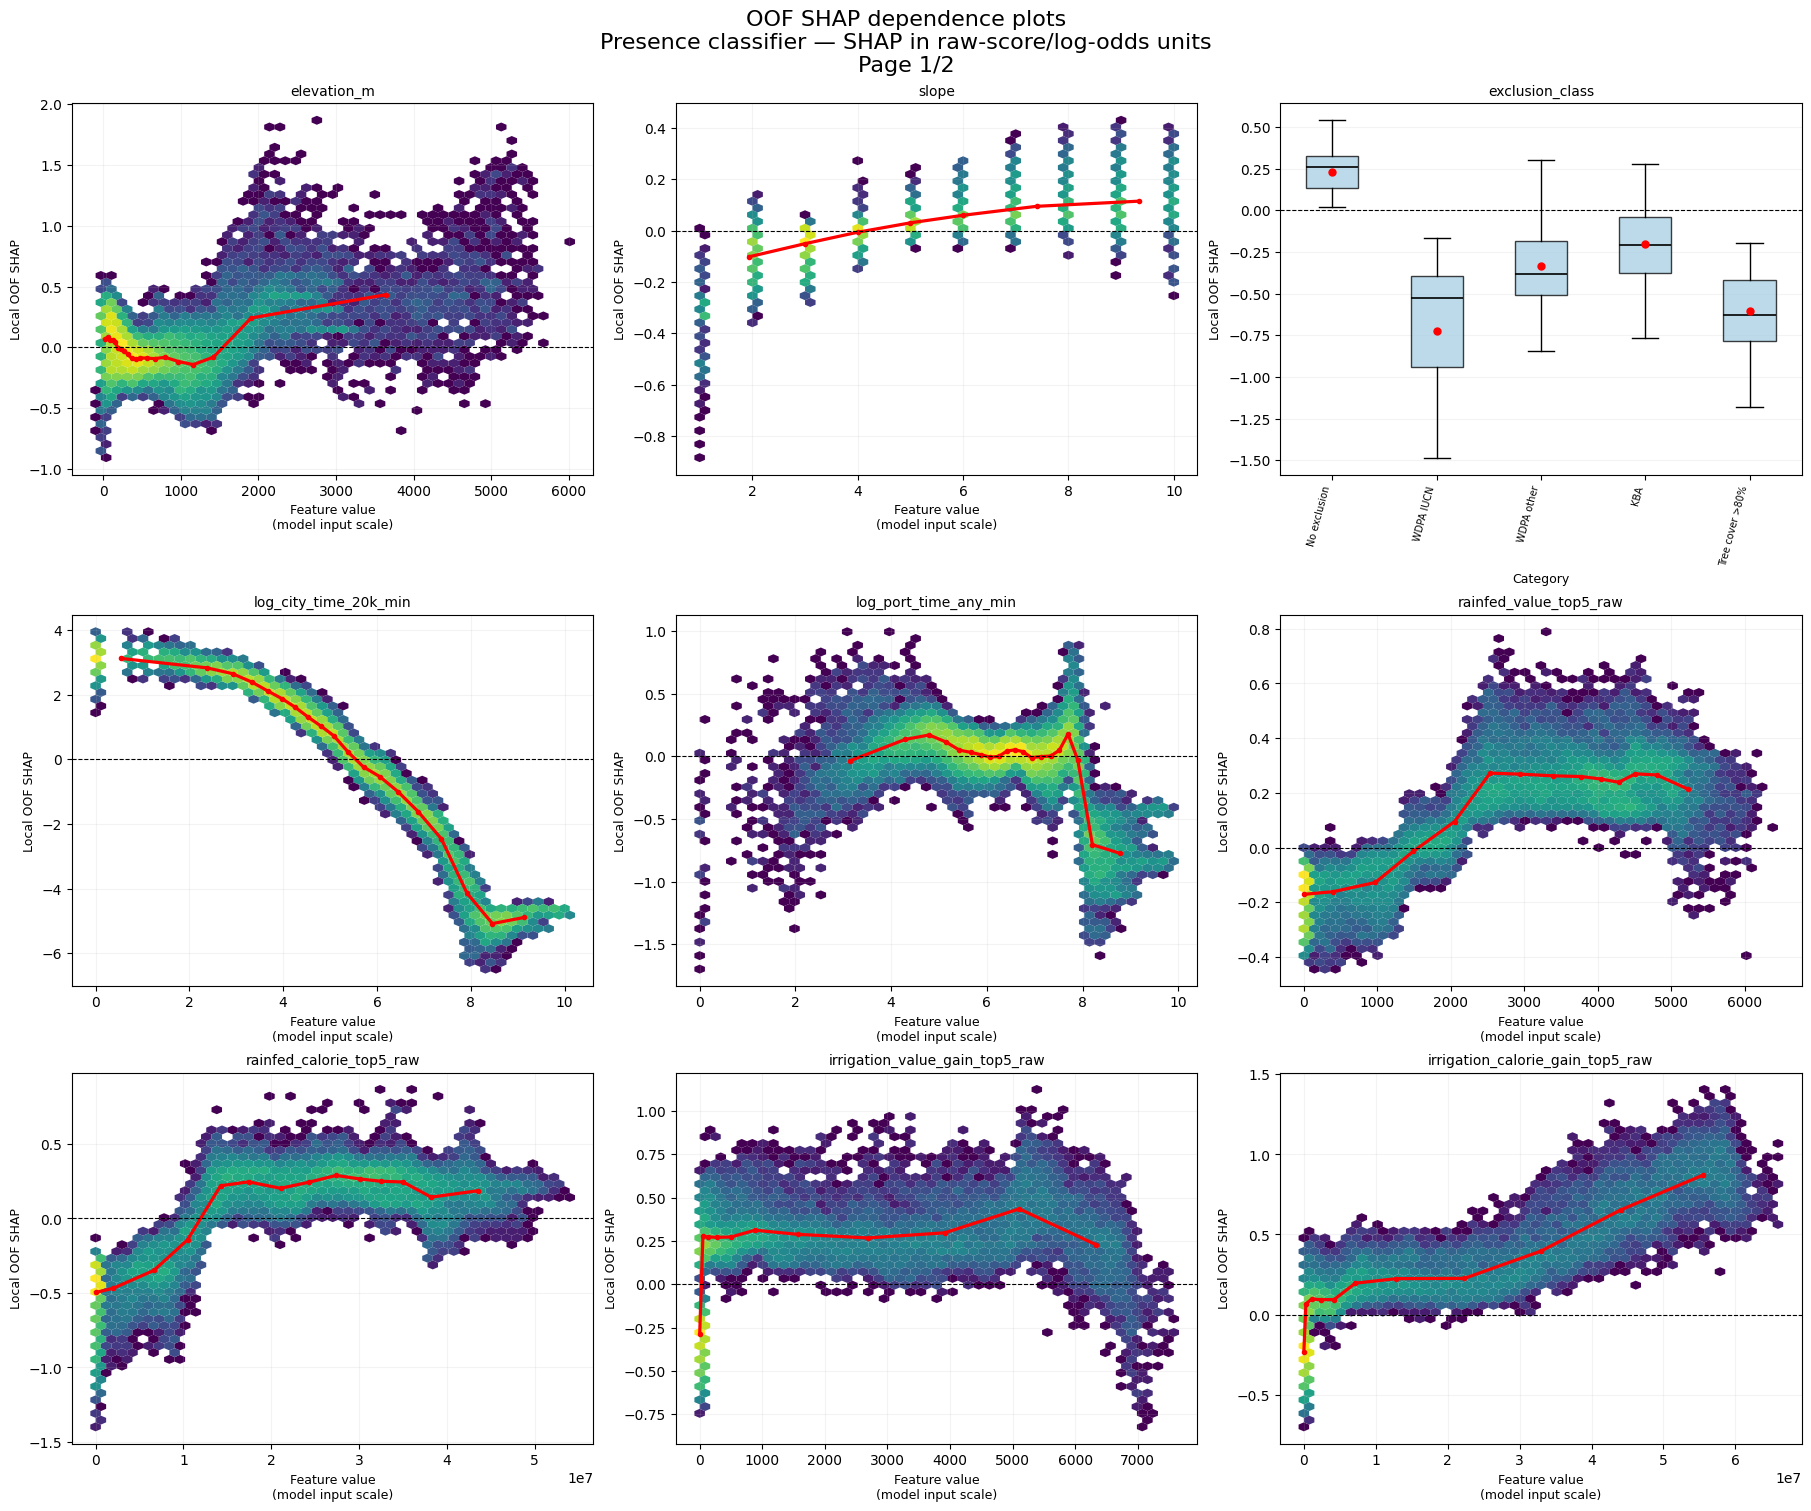

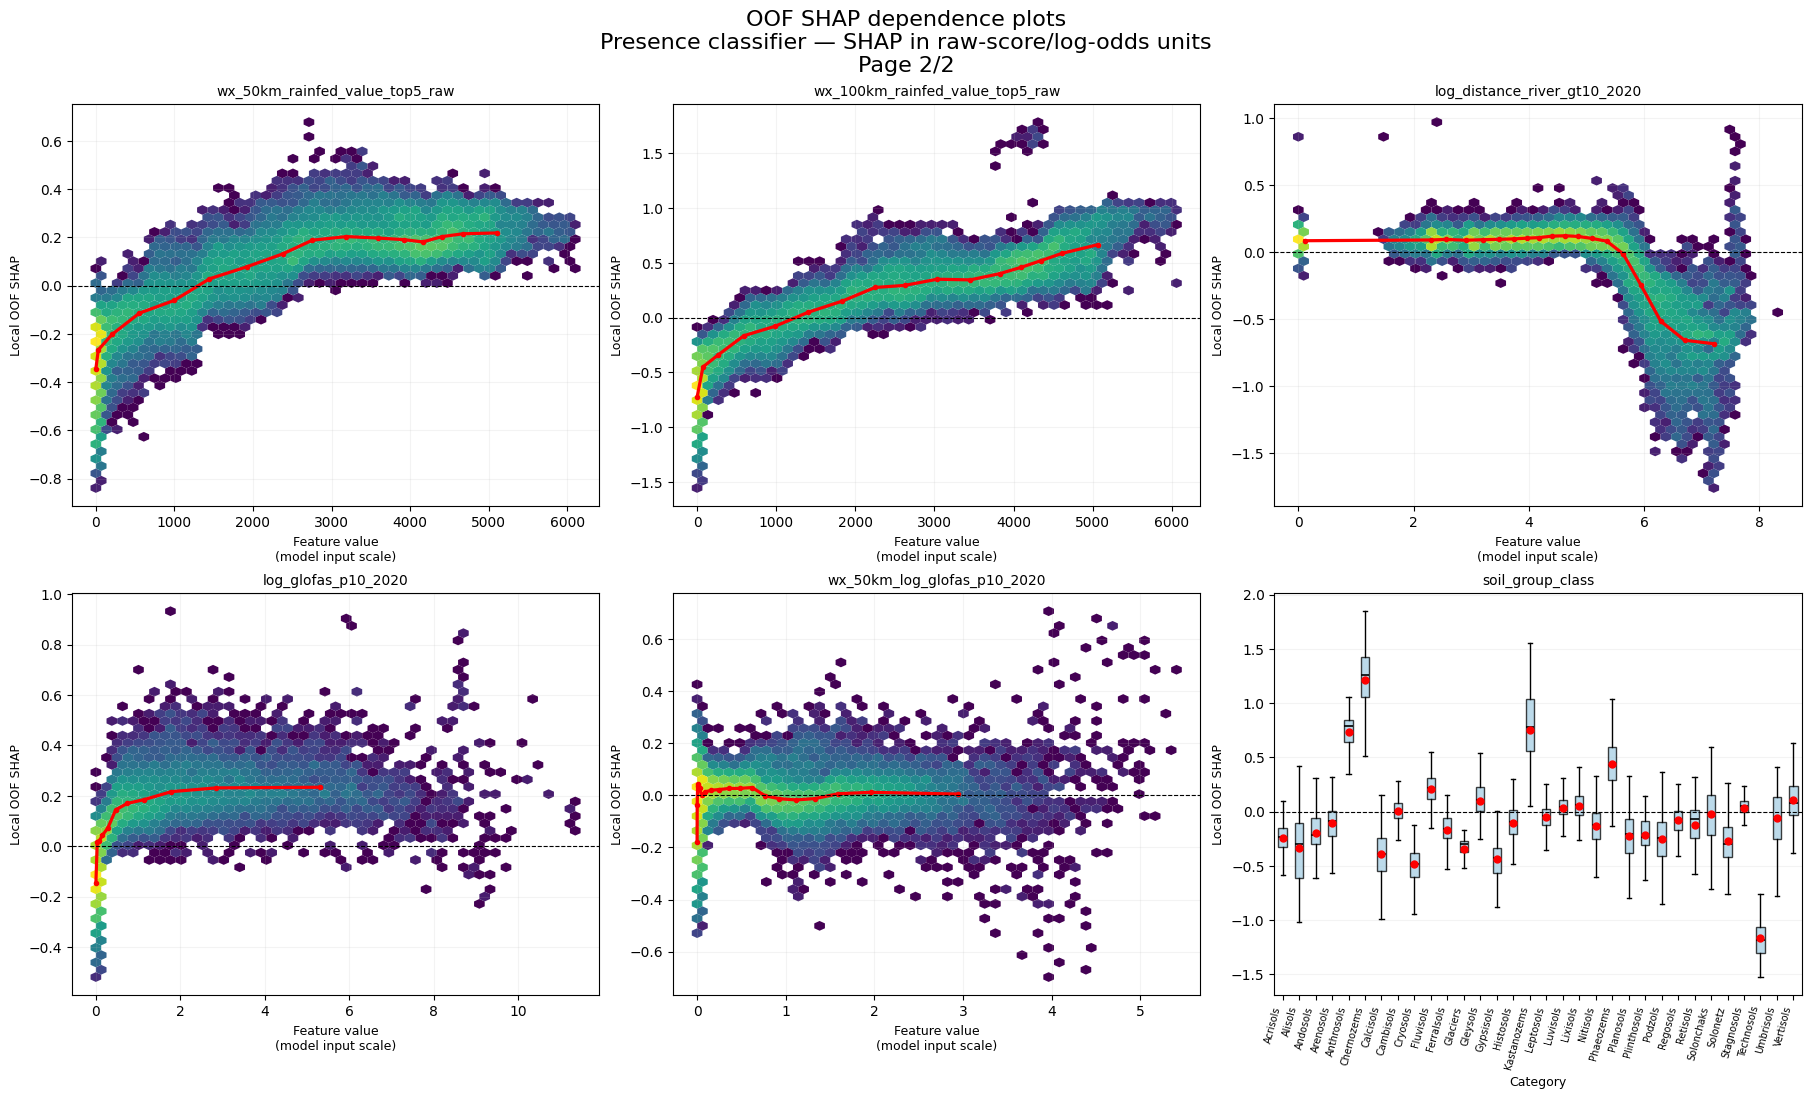

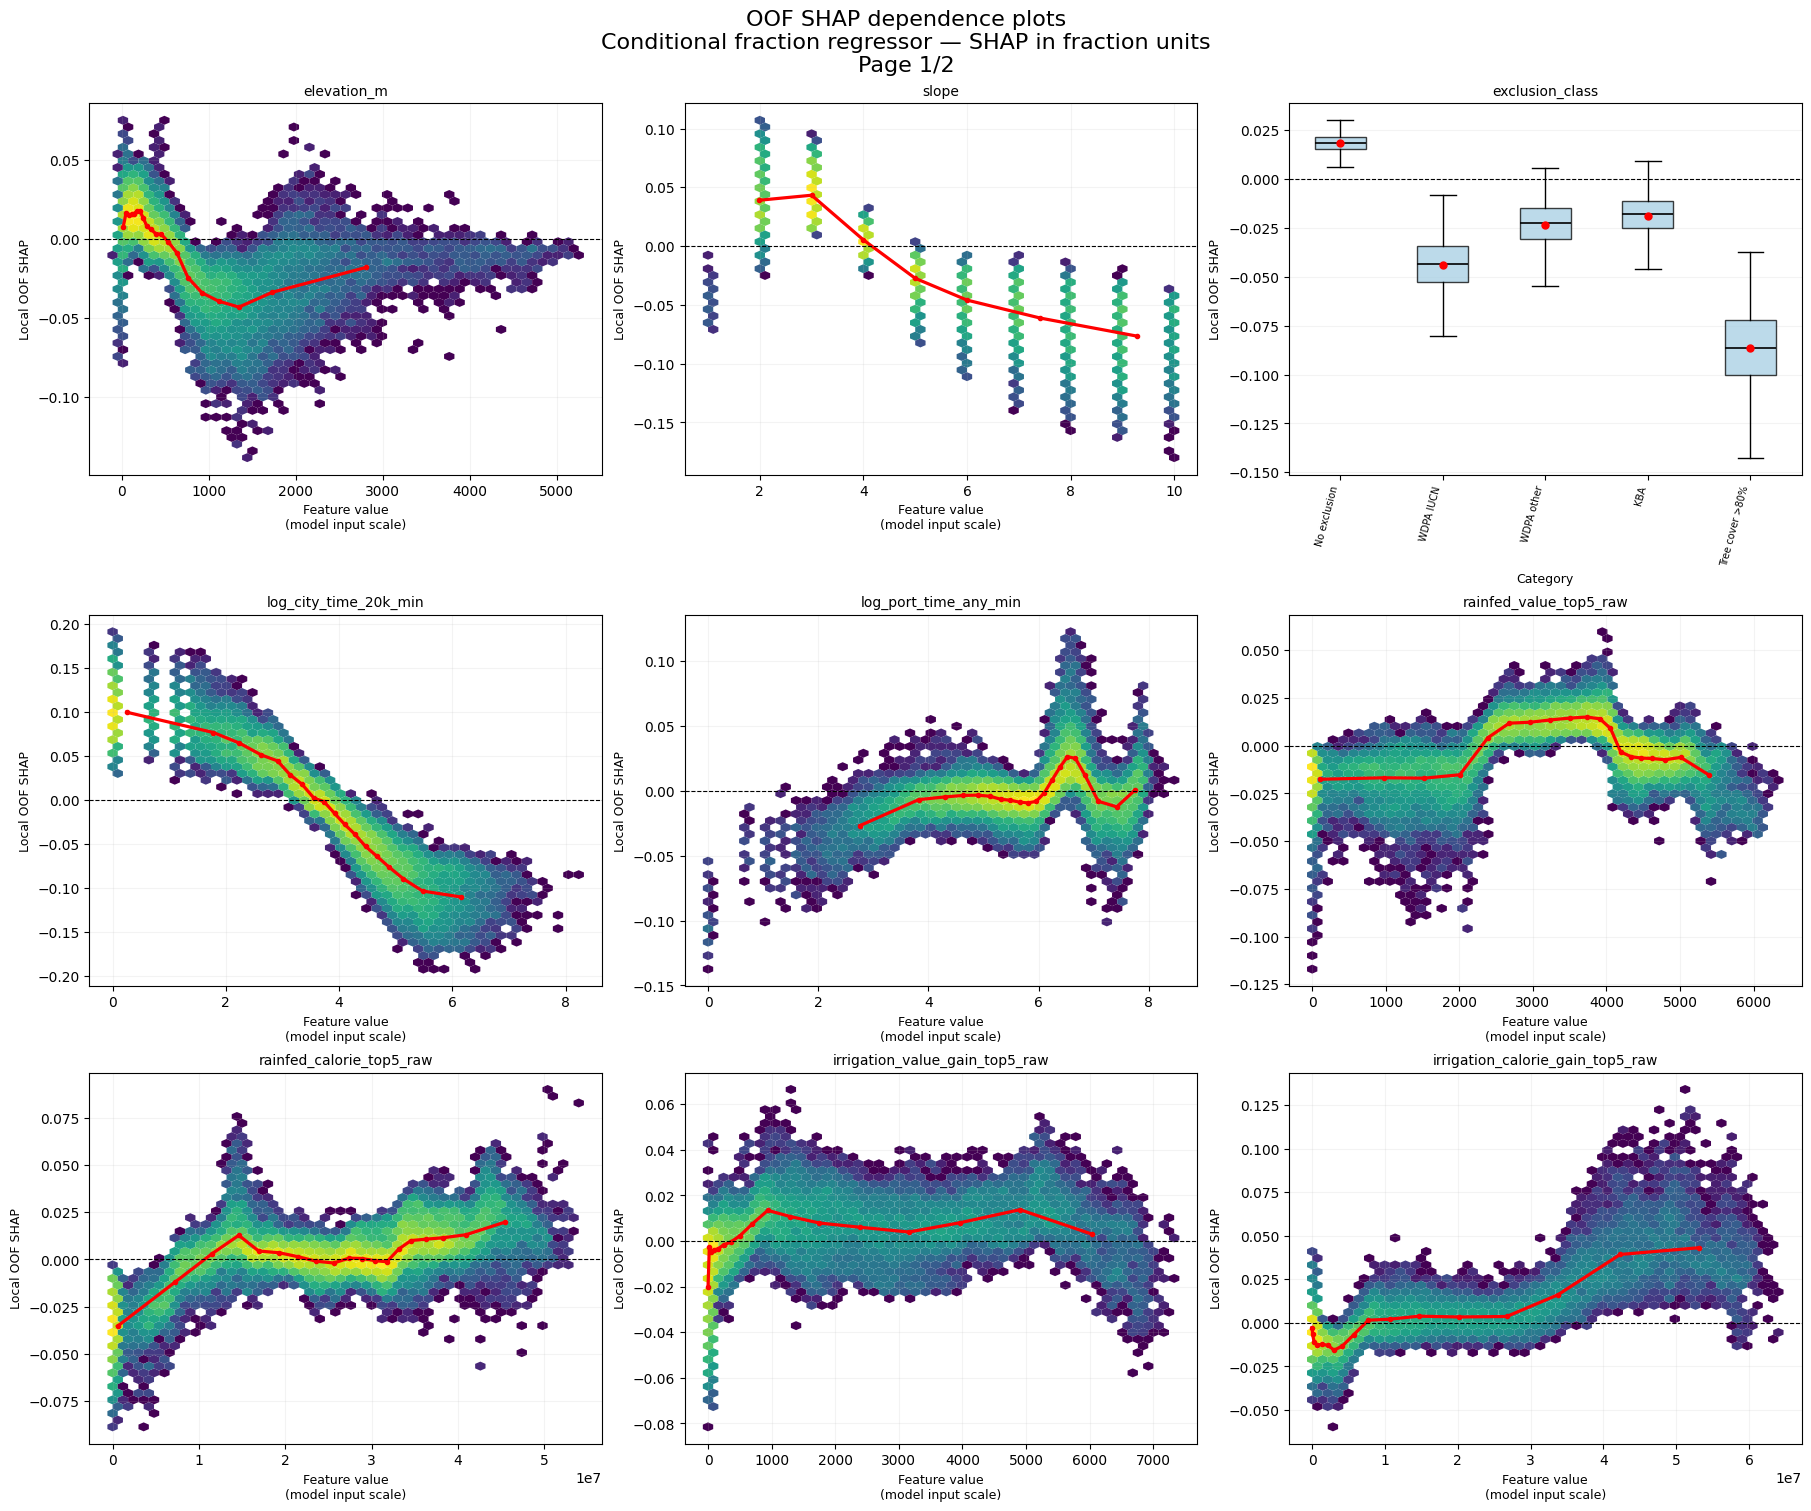

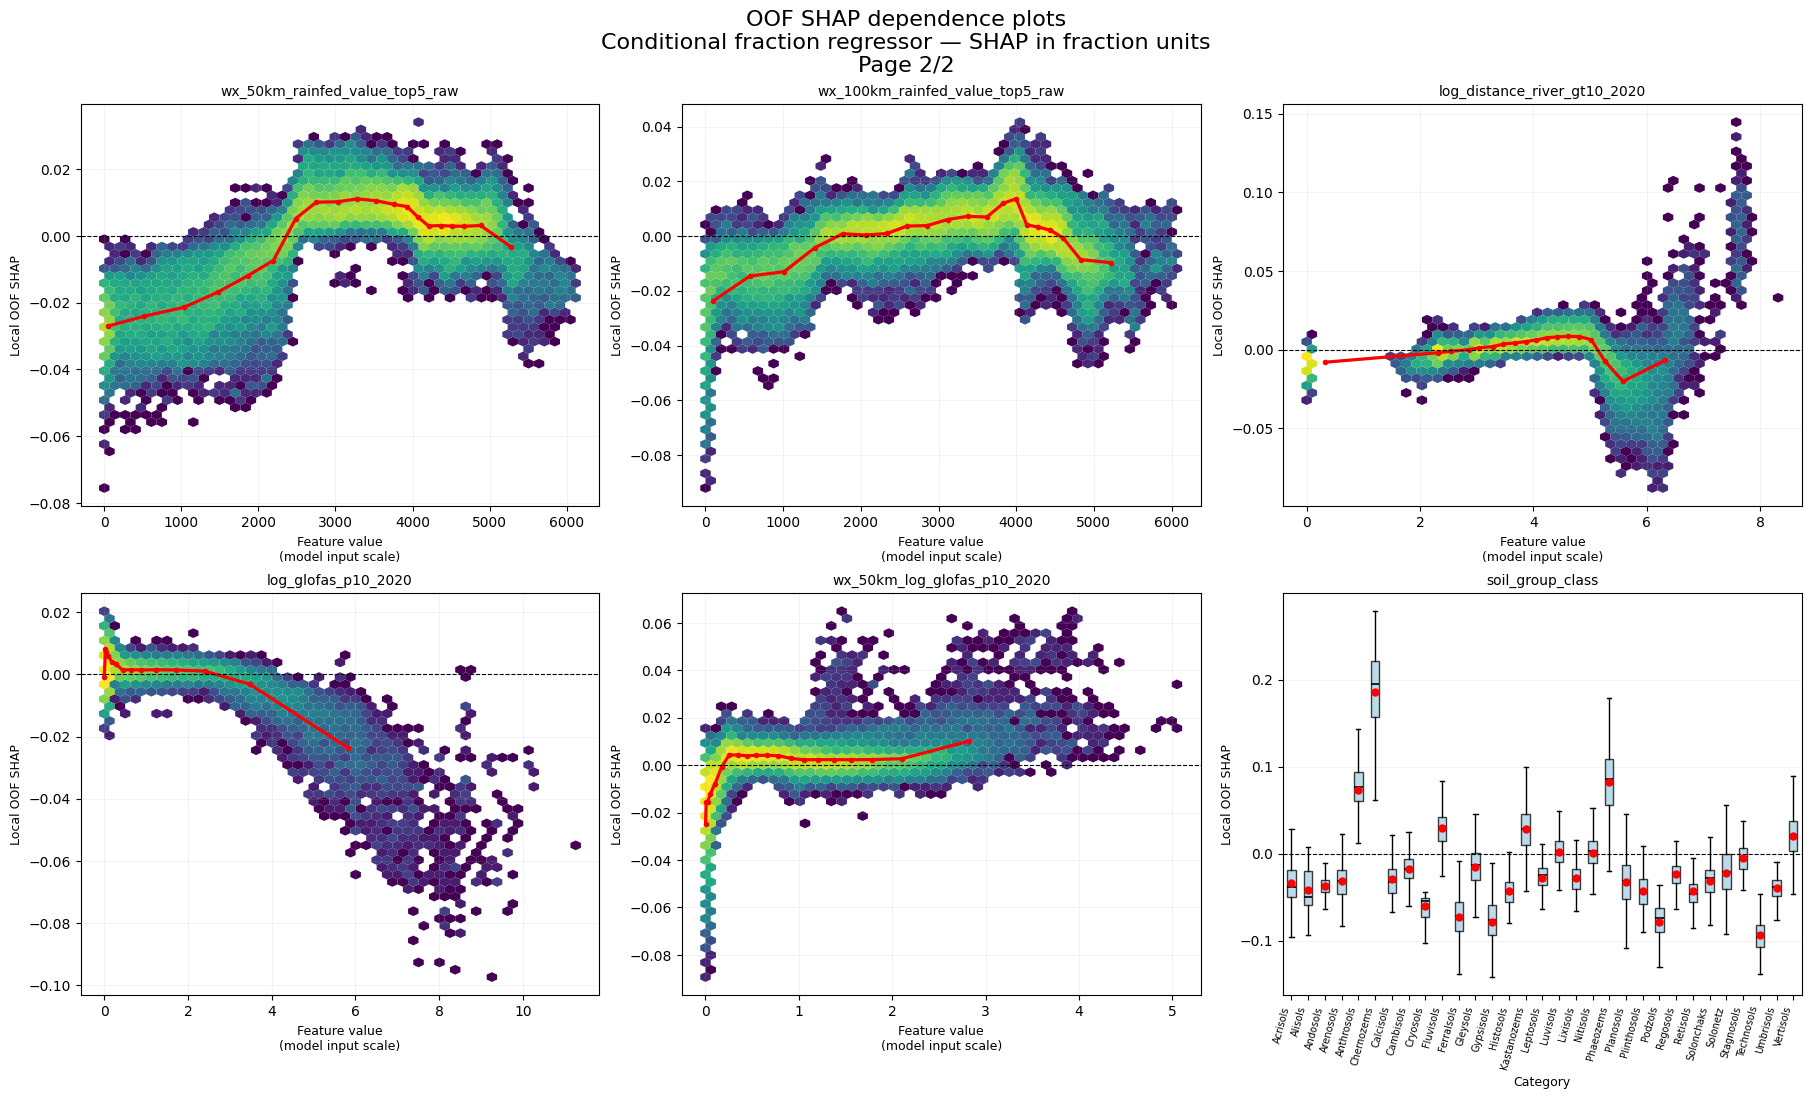

In [14]:
# ============================================================
# 個別説明変数の値とOOF SHAP値の関係
# ============================================================

import gc
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap


# ------------------------------------------------------------
# 0. 設定
# ------------------------------------------------------------

DEPENDENCE_MODEL_NAME = "soil_group_wetland_excluded"

DEPENDENCE_FEATURES = list(
    MODEL_FEATURES[DEPENDENCE_MODEL_NAME]
)

# 各fold・各段階でSHAPを計算する最大セル数
DEPENDENCE_MAX_ROWS_PER_FOLD = 10_000

# 1枚に表示するグラフ数
N_COLS = 3
N_ROWS = 3

# 連続変数の赤線を作る分位点ビン数
N_BINS = 20

# カテゴリ変数を表示する最低標本数
MIN_CATEGORY_N = 20

# Trueなら画像も保存する
SAVE_DEPENDENCE_FIGURES = False

DEPENDENCE_OUTPUT_DIR = (
    OUTPUT_DIR
    / "feature_shap_dependence"
)

if SAVE_DEPENDENCE_FIGURES:
    DEPENDENCE_OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )


# ------------------------------------------------------------
# 1. 必要な変数を確認
# ------------------------------------------------------------

required_objects = [
    "sample",
    "splits",
    "fit_models",
    "extract_tree_shap",
    "MODEL_FEATURES",
    "RANDOM_SEED",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "先にモデル準備セルを実行してください。"
        f"不足: {missing_objects}"
    )


# ------------------------------------------------------------
# 2. カテゴリ変数
# ------------------------------------------------------------

CATEGORICAL_FEATURES = [
    "exclusion_class",
    "soil_group_class",
]


EXCLUSION_LABELS = {
    1: "No exclusion",
    2: "WDPA IUCN",
    3: "WDPA other",
    4: "KBA",
    5: "Permanent wetland",
    6: "Tree cover >80%",
}


# SOIL_LABELSがまだない場合
if "SOIL_LABELS" not in globals():
    SOIL_LABELS = {
        1: "Acrisols",
        2: "Alisols",
        3: "Andosols",
        4: "Arenosols",
        5: "Anthrosols",
        6: "Chernozems",
        7: "Calcisols",
        8: "Cambisols",
        9: "Cryosols",
        10: "Fluvisols",
        11: "Ferralsols",
        12: "Glaciers",
        13: "Gleysols",
        14: "Gypsisols",
        15: "Histosols",
        16: "Islands",
        17: "Kastanozems",
        18: "Leptosols",
        19: "Luvisols",
        20: "Lixisols",
        21: "Nitisols",
        22: "Phaeozems",
        23: "Planosols",
        24: "Plinthosols",
        25: "Podzols",
        26: "Regosols",
        27: "Retisols",
        28: "Solonchaks",
        29: "Solonetz",
        30: "Stagnosols",
        31: "Technosols",
        32: "Umbrisols",
        33: "Vertisols",
        34: "Open Water",
    }


CATEGORY_LABEL_MAPS = {
    "exclusion_class": EXCLUSION_LABELS,
    "soil_group_class": SOIL_LABELS,
}


# ------------------------------------------------------------
# 3. OOFローカルSHAPを再計算
# ------------------------------------------------------------

local_shap_frames = []

for fold_number, (train_idx, test_idx) in enumerate(
    splits,
    start=1,
):
    print("=" * 70)
    print(f"OOF SHAP fold {fold_number}/{len(splits)}")
    print("=" * 70)

    train_df = sample.iloc[train_idx]
    test_df = sample.iloc[test_idx]

    classifier, regressor = fit_models(
        train_df,
        DEPENDENCE_FEATURES,
        fold_number,
    )

    # ========================================================
    # Stage 1：農地の存在
    # ========================================================

    rng_presence = np.random.default_rng(
        RANDOM_SEED
        + 10_000
        + fold_number
    )

    n_presence = min(
        DEPENDENCE_MAX_ROWS_PER_FOLD,
        len(test_df),
    )

    presence_positions = np.sort(
        rng_presence.choice(
            len(test_df),
            size=n_presence,
            replace=False,
        )
    )

    presence_frame = (
        test_df
        .iloc[presence_positions]
        .copy()
    )

    presence_values = extract_tree_shap(
        shap.TreeExplainer(classifier),
        presence_frame[DEPENDENCE_FEATURES],
    )

    presence_feature_values = (
        presence_frame[DEPENDENCE_FEATURES]
        .reset_index(drop=True)
        .copy()
    )

    # category型を保存しやすい整数へ変換
    for feature in CATEGORICAL_FEATURES:
        if feature in presence_feature_values.columns:
            presence_feature_values[feature] = (
                presence_feature_values[feature]
                .astype(int)
            )

    presence_shap_values = pd.DataFrame(
        presence_values,
        columns=[
            f"shap__{feature}"
            for feature in DEPENDENCE_FEATURES
        ],
    )

    presence_result = pd.concat(
        [
            presence_feature_values,
            presence_shap_values,
        ],
        axis=1,
    )

    presence_result.insert(
        0,
        "stage",
        "presence_classifier",
    )

    presence_result.insert(
        1,
        "fold",
        fold_number,
    )

    presence_global_idx = (
        test_idx[presence_positions]
    )

    if (
        "area_weight" in globals()
        and area_weight is not None
    ):
        presence_result["weight"] = (
            area_weight[presence_global_idx]
        )
    else:
        presence_result["weight"] = 1.0

    local_shap_frames.append(
        presence_result
    )

    del presence_frame
    del presence_values
    del presence_feature_values
    del presence_shap_values
    del presence_result

    gc.collect()

    # ========================================================
    # Stage 2：農地がある場合の農地割合
    # ========================================================

    positive_positions = np.flatnonzero(
        test_df["presence"]
        .to_numpy(dtype=np.uint8)
        == 1
    )

    rng_fraction = np.random.default_rng(
        RANDOM_SEED
        + 20_000
        + fold_number
    )

    n_fraction = min(
        DEPENDENCE_MAX_ROWS_PER_FOLD,
        len(positive_positions),
    )

    selected_positive_positions = np.sort(
        rng_fraction.choice(
            positive_positions,
            size=n_fraction,
            replace=False,
        )
    )

    fraction_frame = (
        test_df
        .iloc[selected_positive_positions]
        .copy()
    )

    fraction_values = extract_tree_shap(
        shap.TreeExplainer(regressor),
        fraction_frame[DEPENDENCE_FEATURES],
    )

    fraction_feature_values = (
        fraction_frame[DEPENDENCE_FEATURES]
        .reset_index(drop=True)
        .copy()
    )

    for feature in CATEGORICAL_FEATURES:
        if feature in fraction_feature_values.columns:
            fraction_feature_values[feature] = (
                fraction_feature_values[feature]
                .astype(int)
            )

    fraction_shap_values = pd.DataFrame(
        fraction_values,
        columns=[
            f"shap__{feature}"
            for feature in DEPENDENCE_FEATURES
        ],
    )

    fraction_result = pd.concat(
        [
            fraction_feature_values,
            fraction_shap_values,
        ],
        axis=1,
    )

    fraction_result.insert(
        0,
        "stage",
        "conditional_fraction_regressor",
    )

    fraction_result.insert(
        1,
        "fold",
        fold_number,
    )

    fraction_global_idx = (
        test_idx[selected_positive_positions]
    )

    if (
        "area_weight" in globals()
        and area_weight is not None
    ):
        fraction_result["weight"] = (
            area_weight[fraction_global_idx]
        )
    else:
        fraction_result["weight"] = 1.0

    local_shap_frames.append(
        fraction_result
    )

    del fraction_frame
    del fraction_values
    del fraction_feature_values
    del fraction_shap_values
    del fraction_result
    del classifier
    del regressor

    gc.collect()


local_feature_shap = pd.concat(
    local_shap_frames,
    ignore_index=True,
)

del local_shap_frames
gc.collect()

print(
    "local SHAP rows:",
    f"{len(local_feature_shap):,}",
)


# ------------------------------------------------------------
# 4. ローカルSHAPを保存
# ------------------------------------------------------------

local_shap_output_path = (
    OUTPUT_DIR
    / "soil_model_oof_local_feature_shap.csv.gz"
)

local_feature_shap.to_csv(
    local_shap_output_path,
    index=False,
    compression="gzip",
)

print(
    "saved:",
    local_shap_output_path,
)


# ------------------------------------------------------------
# 5. 加重平均を計算する関数
# ------------------------------------------------------------

def weighted_mean(values, weights):
    values = np.asarray(
        values,
        dtype=float,
    )

    weights = np.asarray(
        weights,
        dtype=float,
    )

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if not valid.any():
        return np.nan

    return float(
        np.average(
            values[valid],
            weights=weights[valid],
        )
    )


# ------------------------------------------------------------
# 6. 連続変数の分位点ビン曲線
# ------------------------------------------------------------

def calculate_binned_shap_curve(
    frame,
    feature,
    n_bins=20,
):
    shap_column = f"shap__{feature}"

    temporary = frame[
        [
            feature,
            shap_column,
            "weight",
        ]
    ].copy()

    temporary[feature] = pd.to_numeric(
        temporary[feature],
        errors="coerce",
    )

    temporary[shap_column] = pd.to_numeric(
        temporary[shap_column],
        errors="coerce",
    )

    temporary["weight"] = pd.to_numeric(
        temporary["weight"],
        errors="coerce",
    )

    temporary = temporary.replace(
        [np.inf, -np.inf],
        np.nan,
    ).dropna()

    if len(temporary) == 0:
        return pd.DataFrame()

    unique_count = (
        temporary[feature]
        .nunique()
    )

    actual_bins = min(
        n_bins,
        unique_count,
    )

    if actual_bins < 2:
        return pd.DataFrame()

    temporary["value_bin"] = pd.qcut(
        temporary[feature],
        q=actual_bins,
        duplicates="drop",
    )

    rows = []

    for _, group in temporary.groupby(
        "value_bin",
        observed=True,
    ):
        weights = (
            group["weight"]
            .to_numpy(dtype=float)
        )

        rows.append({
            "feature_value": weighted_mean(
                group[feature],
                weights,
            ),

            "mean_shap": weighted_mean(
                group[shap_column],
                weights,
            ),

            "n": len(group),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("feature_value")
    )


# ------------------------------------------------------------
# 7. 連続変数のdependence plot
# ------------------------------------------------------------

def plot_continuous_dependence(
    ax,
    frame,
    feature,
):
    shap_column = f"shap__{feature}"

    plot_frame = frame[
        [
            feature,
            shap_column,
            "weight",
        ]
    ].copy()

    plot_frame[feature] = pd.to_numeric(
        plot_frame[feature],
        errors="coerce",
    )

    plot_frame[shap_column] = pd.to_numeric(
        plot_frame[shap_column],
        errors="coerce",
    )

    plot_frame = plot_frame.replace(
        [np.inf, -np.inf],
        np.nan,
    ).dropna()

    if len(plot_frame) == 0:
        ax.set_visible(False)
        return

    # 点密度をhexbinで表示
    ax.hexbin(
        plot_frame[feature],
        plot_frame[shap_column],
        gridsize=45,
        mincnt=1,
        bins="log",
        cmap="viridis",
        linewidths=0,
    )

    # 加重平均SHAPの分位点曲線
    curve = calculate_binned_shap_curve(
        plot_frame,
        feature,
        n_bins=N_BINS,
    )

    if not curve.empty:
        ax.plot(
            curve["feature_value"],
            curve["mean_shap"],
            color="red",
            linewidth=2.3,
            marker="o",
            markersize=3,
            label="Area-weighted bin mean",
        )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
    )

    ax.set_title(
        feature,
        fontsize=10,
    )

    ax.set_xlabel(
        "Feature value\n(model input scale)",
        fontsize=9,
    )

    ax.set_ylabel(
        "Local OOF SHAP",
        fontsize=9,
    )

    ax.grid(
        alpha=0.15,
    )


# ------------------------------------------------------------
# 8. カテゴリ変数のdependence plot
# ------------------------------------------------------------

def plot_categorical_dependence(
    ax,
    frame,
    feature,
):
    shap_column = f"shap__{feature}"

    plot_frame = frame[
        [
            feature,
            shap_column,
            "weight",
        ]
    ].copy()

    plot_frame[feature] = pd.to_numeric(
        plot_frame[feature],
        errors="coerce",
    )

    plot_frame[shap_column] = pd.to_numeric(
        plot_frame[shap_column],
        errors="coerce",
    )

    plot_frame = plot_frame.replace(
        [np.inf, -np.inf],
        np.nan,
    ).dropna()

    plot_frame[feature] = (
        plot_frame[feature]
        .astype(int)
    )

    category_counts = (
        plot_frame[feature]
        .value_counts()
        .sort_index()
    )

    valid_categories = (
        category_counts[
            category_counts >= MIN_CATEGORY_N
        ]
        .index
        .tolist()
    )

    if not valid_categories:
        ax.set_visible(False)
        return

    box_values = []
    category_labels = []
    weighted_means = []

    label_map = CATEGORY_LABEL_MAPS.get(
        feature,
        {},
    )

    for category in valid_categories:
        category_frame = plot_frame[
            plot_frame[feature].eq(category)
        ]

        values = (
            category_frame[shap_column]
            .to_numpy(dtype=float)
        )

        weights = (
            category_frame["weight"]
            .to_numpy(dtype=float)
        )

        box_values.append(values)

        category_labels.append(
            label_map.get(
                category,
                str(category),
            )
        )

        weighted_means.append(
            weighted_mean(
                values,
                weights,
            )
        )

    positions = np.arange(
        1,
        len(valid_categories) + 1,
    )

    ax.boxplot(
        box_values,
        positions=positions,
        showfliers=False,
        patch_artist=True,
        boxprops={
            "facecolor": "#A6CEE3",
            "alpha": 0.75,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.2,
        },
    )

    # 赤い点は面積加重平均
    ax.scatter(
        positions,
        weighted_means,
        color="red",
        s=25,
        zorder=5,
        label="Area-weighted mean",
    )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8,
    )

    ax.set_xticks(
        positions
    )

    ax.set_xticklabels(
        category_labels,
        rotation=75,
        ha="right",
        fontsize=7,
    )

    ax.set_title(
        feature,
        fontsize=10,
    )

    ax.set_xlabel(
        "Category",
        fontsize=9,
    )

    ax.set_ylabel(
        "Local OOF SHAP",
        fontsize=9,
    )

    ax.grid(
        axis="y",
        alpha=0.15,
    )


# ------------------------------------------------------------
# 9. 全変数を複数ページに分けて表示
# ------------------------------------------------------------

STAGES = [
    "presence_classifier",
    "conditional_fraction_regressor",
]

STAGE_TITLES = {
    "presence_classifier":
        "Presence classifier — SHAP in raw-score/log-odds units",

    "conditional_fraction_regressor":
        "Conditional fraction regressor — SHAP in fraction units",
}


def plot_all_feature_dependence(
    local_shap_data,
    stage,
    features,
):
    stage_frame = local_shap_data[
        local_shap_data["stage"].eq(stage)
    ].copy()

    plots_per_page = (
        N_COLS
        * N_ROWS
    )

    n_pages = math.ceil(
        len(features)
        / plots_per_page
    )

    for page_number in range(n_pages):
        start = (
            page_number
            * plots_per_page
        )

        end = min(
            start + plots_per_page,
            len(features),
        )

        page_features = features[
            start:end
        ]

        fig, axes = plt.subplots(
            N_ROWS,
            N_COLS,
            figsize=(18, 15),
            constrained_layout=True,
        )

        axes = np.asarray(
            axes
        ).reshape(-1)

        for ax, feature in zip(
            axes,
            page_features,
        ):
            if feature in CATEGORICAL_FEATURES:
                plot_categorical_dependence(
                    ax,
                    stage_frame,
                    feature,
                )
            else:
                plot_continuous_dependence(
                    ax,
                    stage_frame,
                    feature,
                )

        # 使用しないsubplotを非表示
        for ax in axes[
            len(page_features):
        ]:
            ax.set_visible(False)

        fig.suptitle(
            "OOF SHAP dependence plots\n"
            f"{STAGE_TITLES[stage]}\n"
            f"Page {page_number + 1}/{n_pages}",
            fontsize=16,
        )

        if SAVE_DEPENDENCE_FIGURES:
            figure_path = (
                DEPENDENCE_OUTPUT_DIR
                / (
                    f"{stage}_"
                    f"dependence_page_"
                    f"{page_number + 1}.png"
                )
            )

            fig.savefig(
                figure_path,
                dpi=200,
                bbox_inches="tight",
            )

            print(
                "saved:",
                figure_path,
            )

        plt.show()


# ------------------------------------------------------------
# 10. PresenceとConditionalを順番に描画
# ------------------------------------------------------------

for stage in STAGES:
    plot_all_feature_dependence(
        local_shap_data=local_feature_shap,
        stage=stage,
        features=DEPENDENCE_FEATURES,
    )